## Uma análise sobre o desenvolvimento do mercado cinematográfico no Brasil (2000 - 2024).
### Por: Ricardo Morais Pastori, João Rafael Gadelha de Araújo, Victor Hugo Araújo de Vasconcelos, Kaio Vitor Santos de Lima

---

### **Introdução**:

O projeto possui o objetivo de analisar como as dinâmicas de conjuntura e os eventos históricos do Brasil, no século 21, impactaram o desenvolvimento da indústria nacional de cinema. 

A motivação para tal ideia parte da rapidez em como o setor reage ao poder de compra da população e a inovações tecnológicas. Portanto, situar a análise em um período de mudanças profundas na sociedade, nos permite projetar tendências e especular sobre o futuro do cinema no Brasil.

---

### **Dados usados e Exploração dos dados**:

#### relação_sala_publico (1971-2024):

Coletado por meio de web scraping e dos anuários da Ancine. 

Quantidade de salas de cinemas, público atendido e a relação salas por público.

In [1256]:
import pandas as pd

In [1257]:
%load_ext autoreload
%autoreload 2

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from funcoes import coleta_tabelas

options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

sala_publico_71_18 = coleta_tabelas(meu_navegador, 'ano', "2018", "R24", "960")

sala_publico_71_18.to_csv('dados_brutos/sala_publico_71_18.csv', index=False)
sala_publico_71_18

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=146.0.7680.178)
Stacktrace:
	chromedriver!GetHandleVerifier [0x73cdf3+10b03]
	chromedriver!GetHandleVerifier [0x73cf24+10c34]
	chromedriver!(No symbol) [0x522120]
	chromedriver!(No symbol) [0x500c53]
	chromedriver!(No symbol) [0x59431b]
	chromedriver!(No symbol) [0x5aa309]
	chromedriver!(No symbol) [0x58d8a6]
	chromedriver!(No symbol) [0x560229]
	chromedriver!(No symbol) [0x560fe4]
	chromedriver!GetHandleVerifier [0x9a48b9+2785c9]
	chromedriver!GetHandleVerifier [0x99feb5+273bc5]
	chromedriver!GetHandleVerifier [0x9be06b+291d7b]
	chromedriver!GetHandleVerifier [0x755cc8+299d8]
	chromedriver!GetHandleVerifier [0x75d9fd+3170d]
	chromedriver!GetHandleVerifier [0x7458c8+195d8]
	chromedriver!GetHandleVerifier [0x745a92+197a2]
	chromedriver!GetHandleVerifier [0x72ee9a+2baa]
	KERNEL32!BaseThreadInitThunk [0x75cb5d49+19]
	ntdll!RtlInitializeExceptionChain 

In [ ]:
sala_publico_71_18 = pd.read_csv('dados_brutos/sala_publico_71_18.csv')

In [ ]:
sala_publico_71_18.info()

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       52 non-null     str    
 1   1       53 non-null     str    
 2   2       51 non-null     str    
 3   3       52 non-null     str    
 4   4       0 non-null      float64
 5   5       1 non-null      str    
 6   6       0 non-null      float64
 7   7       1 non-null      str    
 8   8       0 non-null      float64
 9   9       1 non-null      str    
 10  10      0 non-null      float64
 11  11      0 non-null      float64
 12  12      0 non-null      float64
 13  13      0 non-null      float64
 14  14      0 non-null      float64
 15  15      0 non-null      float64
 16  16      0 non-null      float64
 17  17      0 non-null      float64
 18  18      0 non-null      float64
 19  19      0 non-null      float64
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      0 non-n

Valores numéricos estão como string.

In [ ]:
sala_publico_71_18.isna().sum()

0      6
1      5
2      7
3      6
4     58
5     57
6     58
7     57
8     58
9     57
10    58
11    58
12    58
13    58
14    58
15    58
16    58
17    58
18    58
19    58
20    58
21    58
22    58
dtype: int64

Muitos valores nulos.

O processo de scraping via Selenium gera uma tabela mal estruturada com diversos valores nulos e com informações da página do site, como o rodapé. No entanto, retorna os valores que precisamos.

In [ ]:
import pdfplumber

with pdfplumber.open("anuario-do-audiovisual-brasileiro-2024.pdf") as pdf:
    primeira_pagina = pdf.pages[12]
    texto = primeira_pagina.extract_table()
    sala_publico_15_24 = pd.DataFrame(texto)

sala_publico_15_24.to_csv('dados_brutos/sala_publico_15_24.csv', index=False)
sala_publico_15_24

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Indicadores,NaN,NaN,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Público,NaN,NaN,173.022.827,184.327.360,181.226.407,163.454.506,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
2,Renda (R$),NaN,NaN,2.351.590.807,2.599.327.628,2.717.664.735,2.458.271.967,2.809.994.860,628.681.962,913.669.053,1.819.558.008,2.237.076.190,2.490.285.189
3,Títulos lançados,NaN,NaN,455,458,463,472,452,174,309,385,415,456
4,,Preço Médio do,,14,14,15,15,16,16,17,19,20,20
5,NaN,Ingresso (R$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,,Complexos em,,742,771,782,809,852,466,766,812,841,866
7,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,,Salas em,,3.005,3.160,3.223,3.347,3.507,1.860,3.266,3.415,3.468,3.510
9,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sala_publico_15_24.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       11 non-null     str  
 1   1       12 non-null     str  
 2   2       5 non-null      str  
 3   3       11 non-null     str  
 4   4       11 non-null     str  
 5   5       11 non-null     str  
 6   6       11 non-null     str  
 7   7       11 non-null     str  
 8   8       11 non-null     str  
 9   9       11 non-null     str  
 10  10      11 non-null     str  
 11  11      11 non-null     str  
 12  12      11 non-null     str  
dtypes: str(13)
memory usage: 2.8 KB


Valores numéricos estão como string.

In [ ]:
sala_publico_15_24.isna().sum()

0      6
1      5
2     12
3      6
4      6
5      6
6      6
7      6
8      6
9      6
10     6
11     6
12     6
dtype: int64

O mesmo processo ocorre com a extração dos dados do anuário da Ancine via pdfpumbler.

---

#### pop_estados (2021-2024):

Coletado por meio do site do IBGE.

Quantidade de habitantes por estado.

In [ ]:
populacao_estado = pd.read_csv('dados/pop_estados_2022.csv', sep=';')
populacao_estado

,Unidade da Federação,População residente
0,São Paulo,45736978
1,Minas Gerais,21178401
2,Rio de Janeiro,17211760
3,Bahia,14811339
4,Paraná,11686692
5,Rio Grande do Sul,11220506
6,Pernambuco,9493026
7,Ceará,9162955
8,Pará,8570045
9,Santa Catarina,7796817


In [ ]:
populacao_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Unidade da Federação  28 non-null     str  
 1   População residente   28 non-null     int64
dtypes: int64(1), str(1)
memory usage: 850.0 bytes


In [ ]:
populacao_estado.describe()

,População residente
count,2.800000e+01
mean,1.506164e+07
std,3.942475e+07
min,6.734040e+05
25%,2.927914e+06
50%,4.152908e+06
75%,9.924896e+06
max,2.108630e+08


In [ ]:
populacao_estado.isna().sum()

Unidade da Federação    0
População residente     0
dtype: int64

---

#### publico_filmes_br (2021-2024):

Coletado a partir dos anuários da OCA (Observatório Brasileiro do Cinema e do Audiovisual).

Quantidade de público de filmes nacionais.

In [ ]:
publico_nacionais = pd.read_csv('dados/publico_filmes_br_2022.csv')
publico_nacionais

,UF do complexo,Público
0,AC,275294
1,AL,1066720
2,AM,1656803
3,AP,377817
4,BA,3435948
5,CE,2964062
6,DF,2742188
7,ES,1648801
8,GO,2787744
9,MA,1306064


In [ ]:
publico_nacionais.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   UF do complexo  28 non-null     str  
 1   Público         28 non-null     int64
dtypes: int64(1), str(1)
memory usage: 639.0 bytes


In [ ]:
publico_nacionais.isna().sum()

UF do complexo    0
Público           0
dtype: int64

---

#### ingressos_per_capita (2004-2020):

Coletado por meio de web scraping do site Filmb.

Quantidade de ingressos vendidos por pessoa em um estado.

In [ ]:
%load_ext autoreload
%autoreload 2

import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from constantes import (
    COLETA_INGRESSOS_PER_CAPITA
)

from funcoes import coleta_ingressos_per_capita

# Configura o navegador
options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

for ano in range(2020, 2003, -1):

    texto_busca = COLETA_INGRESSOS_PER_CAPITA
    
    df_temp = coleta_ingressos_per_capita(meu_navegador, texto_busca, ano)

    df_temp.to_csv(f'dados_brutos/ingressos_per_capita_por_estado_{ano}.csv', index=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1351]:
ingressos_per_capita = pd.read_csv('dados_brutos/ingressos_per_capita_por_estado_2010.csv')
ingressos_per_capita

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,--> Busca Em todos os anos 2017 2016 2015 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Busca Em todos os anos 2017 2016 2015 2014 ...,NaN,Menu,NaN,Imprimir,NaN,Anterior,NaN,Próximo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Database Brasil 2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,20. Ingressos per capita dos estados,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,estadosalaspúblicopopulaçãoingressos per capit...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,estado,salas,público,população,ingressos per capita,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,Distrito Federal,80,5.019.033,2.562.963,196,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2,Rio de Janeiro,271,21.050.005,15.993.583,132,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Os valores da coluna ingressos per capita não representam seus valores reais.

196 deveria representar 1.96.

In [ ]:
ingressos_per_capita.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       31 non-null     str    
 1   1       34 non-null     str    
 2   2       31 non-null     str    
 3   3       33 non-null     str    
 4   4       31 non-null     str    
 5   5       32 non-null     str    
 6   6       0 non-null      float64
 7   7       1 non-null      str    
 8   8       0 non-null      float64
 9   9       1 non-null      str    
 10  10      0 non-null      float64
 11  11      0 non-null      float64
 12  12      0 non-null      float64
 13  13      0 non-null      float64
 14  14      0 non-null      float64
 15  15      0 non-null      float64
 16  16      0 non-null      float64
 17  17      0 non-null      float64
 18  18      0 non-null      float64
 19  19      0 non-null      float64
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      0 non-n

In [ ]:
ingressos_per_capita.isna().sum()

0      8
1      5
2      8
3      6
4      8
5      7
6     39
7     38
8     39
9     38
10    39
11    39
12    39
13    39
14    39
15    39
16    39
17    39
18    39
19    39
20    39
21    39
22    39
dtype: int64

---

#### ranking_municipios (2004-2020):

Coletado por meio de web scraping do site Filmb.

Quantidade de salas de cinema nos municípios brasileiros.

In [ ]:
%load_ext autoreload
%autoreload 2

import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd

from constantes import (
    COLETA_RANKING_MUNICIPIOS_2020_2007,
    COLETA_RANKING_MUNICIPIOS_2006_2005,
    COLETA_RANKING_MUNICIPIOS_2004
)

from funcoes import coleta_ranking_municipios

# Configura o navegador
options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

for ano in range(2020, 2003, -1):

    if ano >= 2007:
        texto_busca = COLETA_RANKING_MUNICIPIOS_2020_2007
    elif ano >= 2005:
        texto_busca = COLETA_RANKING_MUNICIPIOS_2006_2005
    elif ano == 2004:
        texto_busca = COLETA_RANKING_MUNICIPIOS_2004

    df_temp = coleta_ranking_municipios(meu_navegador, texto_busca, ano)
    df_temp.to_csv(f'dados_brutos/ranking_municipios_{ano}.csv', index=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
sala_por_municipio = pd.read_csv('dados_brutos/ranking_municipios_2009.csv')
sala_por_municipio

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,--> Busca Em todos os anos 2017 2016 2015 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Busca Em todos os anos 2017 2016 2015 2014 ...,NaN,Menu,NaN,Imprimir,NaN,Anterior,NaN,Próximo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Database Brasil 2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,134,Ilheus,BA,1,2,"0,10%",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,135,Itabuna,BA,1,2,"0,10%",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
375,Fonte: Banco de dados Filme B - Pesquisa: Filme B,Fonte: Banco de dados Filme B - Pesquisa: Filme B,Fonte: Banco de dados Filme B - Pesquisa: Filme B,Fonte: Banco de dados Filme B - Pesquisa: Filme B,Fonte: Banco de dados Filme B - Pesquisa: Filme B,Fonte: Banco de dados Filme B - Pesquisa: Filme B,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
376,"Observações: * Segundo o IBGE, Brasília é o ún...","Observações: * Segundo o IBGE, Brasília é o ún...","Observações: * Segundo o IBGE, Brasília é o ún...","Observações: * Segundo o IBGE, Brasília é o ún...","Observações: * Segundo o IBGE, Brasília é o ún...","Observações: * Segundo o IBGE, Brasília é o ún...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sala_por_municipio.isna().sum()

0       7
1       5
2       7
3       6
4       8
5       7
6     378
7     377
8     378
9     377
10    378
11    378
12    378
13    378
14    378
15    378
16    378
17    378
18    378
19    378
20    378
21    378
22    378
dtype: int64

In [ ]:
sala_por_municipio.info()

<class 'pandas.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       371 non-null    str    
 1   1       373 non-null    str    
 2   2       371 non-null    str    
 3   3       372 non-null    str    
 4   4       370 non-null    str    
 5   5       371 non-null    str    
 6   6       0 non-null      float64
 7   7       1 non-null      str    
 8   8       0 non-null      float64
 9   9       1 non-null      str    
 10  10      0 non-null      float64
 11  11      0 non-null      float64
 12  12      0 non-null      float64
 13  13      0 non-null      float64
 14  14      0 non-null      float64
 15  15      0 non-null      float64
 16  16      0 non-null      float64
 17  17      0 non-null      float64
 18  18      0 non-null      float64
 19  19      0 non-null      float64
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      0 non

---

#### sala_região_2015_2020:

Os dados referentes aos anos de 2015-2024 foram coletados a partir dos anuários da Ancine.

Quantidade de salas de cinema em determinada região.

In [ ]:
import pdfplumber

with pdfplumber.open("anuario-do-audiovisual-brasileiro-2024.pdf") as pdf:
    primeira_pagina = pdf.pages[74]
    texto = primeira_pagina.extract_table()
    sala_por_regiao = pd.DataFrame(texto)

sala_por_regiao.to_csv('dados_brutos/sala_por_regiao.csv')
sala_por_regiao

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Região,Salas em funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Variação\n2023 x 2024,Variação\n2015 x 2024
1,NaN,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,NaN,NaN
2,Centro-Oeste,258,274,279,285,286,170,280,285,293,288,"-1,7%","11,6%"
3,Nordeste,446,490,513,548,586,356,529,600,597,598,"0,2%","34,1%"
4,Norte,194,198,212,228,235,169,204,221,222,227,"2,3%","17,0%"
5,Sudeste,1.660,1.728,1.718,1.761,1.846,1.012,1.739,1.774,1.815,1.839,"1,3%","10,8%"
6,Sul,447,470,501,525,554,153,514,535,541,558,"3,1%","24,8%"
7,Brasil,3.005,3.160,3.223,3.347,3.507,1.860,3.266,3.415,3.468,3.510,"1,2%","16,8%"


In [ ]:
sala_por_regiao.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       7 non-null      str  
 1   1       8 non-null      str  
 2   2       7 non-null      str  
 3   3       7 non-null      str  
 4   4       7 non-null      str  
 5   5       7 non-null      str  
 6   6       7 non-null      str  
 7   7       7 non-null      str  
 8   8       7 non-null      str  
 9   9       7 non-null      str  
 10  10      7 non-null      str  
 11  11      7 non-null      str  
 12  12      7 non-null      str  
dtypes: str(13)
memory usage: 1.4 KB


Valores numéricos estão como texto.

In [ ]:
sala_por_regiao.isna().sum()

0     1
1     0
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
dtype: int64

---

#### qtd_salas_por_UF (2015-2024):

Coletado via scraping dos anuários da Ancine.

Quantidade de salas de cinemas por estado.

In [ ]:
import pdfplumber

with pdfplumber.open("anuario-do-audiovisual-brasileiro-2024.pdf") as pdf:
    primeira_pagina = pdf.pages[75]
    texto = primeira_pagina.extract_table()
    sala_por_estado = pd.DataFrame(texto)

sala_por_estado.to_csv('dados_brutos/sala_por_estado.csv', index=False)
sala_por_estado

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,,UF,,,2015,,,2016,,,...,,,2022,,,2023,,,2024,
1,,AC,,,4,,,5,,,...,,,7,,,7,,,7,
2,,AL,,,29,,,29,,,...,,,31,,,31,,,32,
3,,AM,,,63,,,63,,,...,,,59,,,60,,,63,
4,,AP,,,17,,,17,,,...,,,15,,,15,,,15,
5,,BA,,,87,,,100,,,...,,,139,,,140,,,143,
6,,CE,,,86,,,98,,,...,,,111,,,112,,,111,
7,,DF,,,87,,,88,,,...,,,84,,,79,,,80,
8,,ES,,,69,,,72,,,...,,,69,,,71,,,72,
9,,GO,,,99,,,113,,,...,,,109,,,118,,,119,


Percebe-se a adição de mais colunas do que deveriam.

In [ ]:
sala_por_estado.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
dtype: int64

In [ ]:
sala_por_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       29 non-null     str  
 1   1       29 non-null     str  
 2   2       29 non-null     str  
 3   3       29 non-null     str  
 4   4       29 non-null     str  
 5   5       29 non-null     str  
 6   6       29 non-null     str  
 7   7       29 non-null     str  
 8   8       29 non-null     str  
 9   9       29 non-null     str  
 10  10      29 non-null     str  
 11  11      29 non-null     str  
 12  12      29 non-null     str  
 13  13      29 non-null     str  
 14  14      29 non-null     str  
 15  15      29 non-null     str  
 16  16      29 non-null     str  
 17  17      29 non-null     str  
 18  18      29 non-null     str  
 19  19      29 non-null     str  
 20  20      29 non-null     str  
 21  21      29 non-null     str  
 22  22      29 non-null     str  
 23  23      29 non-null     str 

Valores numéricos como texto.

---

#### media_habitantes_por_sala (2001-2020):

Coletado por meio de web scraping do site Filmeb.

Quantidade de salas de cinemas por habitantes em todos os estados do país.

In [ ]:
%load_ext autoreload
%autoreload 2

import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from funcoes import coleta_media_habitantes

# Configura o navegador
options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

for ano in range(2020, 2000, -1):
    
    df_temp = coleta_media_habitantes(meu_navegador, 'estado', ano)

    df_temp.to_csv(f'dados_brutos/media_habitantes_por_sala_{ano}.csv', index=False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
hab_por_sala = pd.read_csv('dados_brutos/media_habitantes_por_sala_2001.csv')
hab_por_sala

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,--> Busca Em todos os anos 2017 2016 2015 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Busca Em todos os anos 2017 2016 2015 2014 ...,NaN,Menu,NaN,Imprimir,NaN,Anterior,NaN,Próximo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Database Brasil 2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,16. Ranking de habitantes por salas dos estados,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,estadon° de salaspop. estadohab. por sala1Dist...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,estado,n° de salas,pop. estado,hab. por sala,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,Distrito Federal,75,2.051.146,27.349,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2,São Paulo,582,37.032.403,63.630,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
hab_por_sala.isna().sum()

0      8
1      5
2      7
3      6
4      8
5     37
6     38
7     37
8     38
9     37
10    38
11    37
12    38
13    38
14    38
15    38
16    38
17    38
18    38
19    38
20    38
21    38
22    38
dtype: int64

In [ ]:
hab_por_sala.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       30 non-null     str    
 1   1       33 non-null     str    
 2   2       31 non-null     str    
 3   3       32 non-null     str    
 4   4       30 non-null     str    
 5   5       1 non-null      str    
 6   6       0 non-null      float64
 7   7       1 non-null      str    
 8   8       0 non-null      float64
 9   9       1 non-null      str    
 10  10      0 non-null      float64
 11  11      1 non-null      str    
 12  12      0 non-null      float64
 13  13      0 non-null      float64
 14  14      0 non-null      float64
 15  15      0 non-null      float64
 16  16      0 non-null      float64
 17  17      0 non-null      float64
 18  18      0 non-null      float64
 19  19      0 non-null      float64
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      0 non-n

Valores numéricos como texto.


















#### coleta_multiplex (2003-2024):

Coletado por meio de web scraping do site Filmb.

Quantidades de salas de cinema em shoppings.


In [ ]:
%load_ext autoreload
%autoreload 2

import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from constantes import (
    COLETA_MULTIPLEX_2020_2011,
    COLETA_MULTIPLEX_2010_2003,
)

from funcoes import coleta_dados_multiplex

# Configura o navegador
options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# Cria uma lista vazia para ir guardando as tabelas
lista_de_tabelas = []

for ano in range(2020, 2002, -1):
    
    # Define qual texto usar baseado no ano
    if ano >= 2011:
        texto_busca = COLETA_MULTIPLEX_2020_2011
    elif ano >= 2007:
        texto_busca = COLETA_MULTIPLEX_2010_2003

    # Coleta a tabela do ano específico
    sala_multiplex = coleta_dados_multiplex(meu_navegador, texto_busca, ano)

    sala_multiplex.to_csv(f'dados_brutos/salas_multiplex_{ano}.csv', index=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
df_multiplex = pd.read_csv('dados_brutos/salas_multiplex_2018.csv')
df_multiplex

,0,1,2,3
0,Total de multiplex por estado,Total de multiplex por estado,Total de multiplex por estado,Total de multiplex por estado
1,UF,cinemas,salas,market share
2,SÃO PAULO,129,863,"32,70%"
3,RIO DE JANEIRO,49,299,"11,30%"
4,MINAS GERAIS,33,190,"7,20%"
5,PARANÁ,26,149,"5,60%"
6,RIO GRANDE DO SUL,22,124,"4,70%"
7,SANTA CATARINA,20,107,"4,10%"
8,PERNAMBUCO,15,101,"3,80%"
9,GOIÁS,15,82,"3,10%"


In [ ]:
df_multiplex = pd.read_csv('dados_brutos/salas_multiplex_2011.csv')
df_multiplex

,0,1,2
0,Total de multiplex por estado,Total de multiplex por estado,Total de multiplex por estado
1,UF,cinemas,salas
2,São Paulo,85,590
3,Rio de Janeiro,28,181
4,Minas Gerais,18,110
5,Paraná,17,98
6,Rio Grande do Sul,12,71
7,Distrito Federal,9,66
8,Santa Catarina,10,56
9,Bahia,6,46


In [ ]:
df_multiplex = pd.read_csv('dados_brutos/salas_multiplex_2010.csv')
df_multiplex

,0,1,2
0,Total de salas multiplex por estado,Total de salas multiplex por estado,Total de salas multiplex por estado
1,UF,total,market share
2,São Paulo,546,"39,2%"
3,Rio de Janeiro,159,"11,4%"
4,Minas Gerais,97,"7,0%"
5,Paraná,88,"6,3%"
6,Distrito Federal,66,"4,7%"
7,Rio Grande do Sul,65,"4,7%"
8,Bahia,46,"3,3%"
9,Pernambuco,41,"2,9%"


In [ ]:
df_multiplex = pd.read_csv('dados_brutos/salas_multiplex_2006.csv')
df_multiplex

,0,1
0,Total de salas multiplex por estado,Total de salas multiplex por estado
1,São Paulo,412
2,Rio de Janeiro,102
3,Minas Gerais,95
4,Paraná,65
5,Distrito Federal,51
6,Rio Grande do Sul,44
7,Pernambuco,36
8,Bahia,26
9,Goiás,22


O que se percebe, nesse caso, é que as tabelas coletadas mudam variante ao ano que elas representam. Isso deve ser levado em conta no tratamento.

#### Despesas por Orgão

In [1464]:
import glob

caminho = "dados/despesas_por_orgao.csv"

arquivos = glob.glob(caminho)

df_orgao = pd.concat([
    pd.read_csv(arq, encoding="latin1", on_bad_lines="skip")
    for arq in arquivos
], ignore_index=True)

df_orgao

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,2025-03-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,4.888592e+11,3.499506e+11,3.529353e+12,7.908355e+10
1,2025-08-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,5.042036e+11,3.816835e+12,3.918003e+12,7.085007e+10
2,2025-05-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,2.564290e+12,3.684896e+12,3.768353e+12,1.956849e+10
3,2025-11-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.457715e+12,5.751897e+12,4.617851e+12,3.109891e+10
4,2025-10-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.486914e+12,4.120151e+11,3.981858e+12,4.080278e+10
...,...,...,...,...,...,...,...
37025,2026-01-01,26000 - MinistÃ©rio da EducaÃ§Ã£o,26258 - Universidade TecnolÃ³gica Federal do P...,7.860688e+12,1.000983e+12,9.914499e+08,1.036689e+12
37026,2026-04-01,39000 - MinistÃ©rio dos Transportes,"29209 - VALEC Engenharia, ConstruÃ§Ãµes e Ferr...",0.000000e+00,2.656945e+08,7.284233e+10,2.724832e+09
37027,2026-02-01,39000 - MinistÃ©rio dos Transportes,"29209 - VALEC Engenharia, ConstruÃ§Ãµes e Ferr...",1.498632e+11,1.650179e+10,1.645884e+10,2.074224e+10
37028,2026-03-01,39000 - MinistÃ©rio dos Transportes,"29209 - VALEC Engenharia, ConstruÃ§Ãµes e Ferr...",1.099398e+11,2.385834e+11,2.649284e+11,4.454586e+11


---

### **Pré-processamento:** 

#### Tratamento para Relação Sala-Público:

Usamos o iloc para selecionar somente a parte da tabela com os dados relevantes para a análise.

In [ ]:
sala_publico_71_18 = sala_publico_71_18.iloc[8:56, 0:4]

In [ ]:
sala_publico_71_18.rename(columns = {'0':'Ano',
                    '1':'Salas',
                    '2':'Público',
                    '3':'Média por Sala'}, inplace=True)
sala_publico_71_18

,Ano,Salas,Público,Média por Sala
8,1971,2.154,203.020.339,94.253
9,1972,2.648,191.489.250,72.315
10,1973,2.690,193.377.651,71.888
11,1974,2.676,201.291.002,75.221
12,1975,3.276,275.380.446,84.060
13,1976,3.161,250.530.851,79.257
14,1977,3.156,208.336.002,66.013
15,1978,2.973,211.657.024,71.193
16,1979,2.937,191.908.000,65.342
17,1980,2.365,164.773.000,69.671


In [ ]:
sala_publico_71_18.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 8 to 55
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Ano             48 non-null     str  
 1   Salas           48 non-null     str  
 2   Público         48 non-null     str  
 3   Média por Sala  48 non-null     str  
dtypes: str(4)
memory usage: 2.9 KB


Convertemos os dados númericos, que eram do tipo string, para int. Fazemos isso acessando uma coluna por vez.

Além disso, resetamos o indice da tabela.

In [ ]:
colunas = list(sala_publico_71_18.columns)

for coluna in colunas:
    sala_publico_71_18[coluna] = sala_publico_71_18[coluna].str.replace('.', '', regex=False).astype(int)

sala_publico_71_18 = sala_publico_71_18.reset_index(drop=True)
sala_publico_71_18

,Ano,Salas,Público,Média por Sala
0,1971,2154,203020339,94253
1,1972,2648,191489250,72315
2,1973,2690,193377651,71888
3,1974,2676,201291002,75221
4,1975,3276,275380446,84060
5,1976,3161,250530851,79257
6,1977,3156,208336002,66013
7,1978,2973,211657024,71193
8,1979,2937,191908000,65342
9,1980,2365,164773000,69671


Para os dados relativos aos anos de 2015-2024, selecionamos os dados das linhas 0, 1 e 8, pois são elas que possuem as informações relevantes que precisamos (ano, público e salas). Além disso, utilizamos o *dropna* para remover qualquer valor nulo na linha.

Além disso, coletamos somente as colunas de 2019 em diante, pois são os anos que faltam no nosso primeiro dataframe.

In [ ]:
sala_publico_15_24

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Indicadores,NaN,NaN,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Público,NaN,NaN,173.022.827,184.327.360,181.226.407,163.454.506,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
2,Renda (R$),NaN,NaN,2.351.590.807,2.599.327.628,2.717.664.735,2.458.271.967,2.809.994.860,628.681.962,913.669.053,1.819.558.008,2.237.076.190,2.490.285.189
3,Títulos lançados,NaN,NaN,455,458,463,472,452,174,309,385,415,456
4,,Preço Médio do,,14,14,15,15,16,16,17,19,20,20
5,NaN,Ingresso (R$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,,Complexos em,,742,771,782,809,852,466,766,812,841,866
7,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,,Salas em,,3.005,3.160,3.223,3.347,3.507,1.860,3.266,3.415,3.468,3.510
9,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sala_publico_15_24 = sala_publico_15_24.loc[[0, 1, 8]].dropna(axis=1)
sala_publico_15_24.drop(columns=0, inplace=True)
sala_publico_15_24 = sala_publico_15_24.iloc[:, 4:12]

sala_publico_15_24

,7,8,9,10,11,12
0,2019,2020,2021,2022,2023,2024
1,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
8,3.507,1.860,3.266,3.415,3.468,3.510


Fazemos a transposição do dataframe e definimos os nomes das colunas com suas informações relativas. Isso possibilita uma melhor leitura dos dados e uma maior facilidade na construção de gráficos.

In [ ]:
sala_publico_15_24 = sala_publico_15_24.transpose()
sala_publico_15_24.columns = ['Ano', 'Público', 'Salas']
sala_publico_15_24 = sala_publico_15_24[['Ano', 'Salas', 'Público']]
sala_publico_15_24

,Ano,Salas,Público
7,2019,3.507,177.719.156
8,2020,1.860,39.437.397
9,2021,3.266,52.267.327
10,2022,3.415,95.287.334
11,2023,3.468,114.076.575
12,2024,3.510,125.256.490


Convertemos o tipo dos dados para int e resetamos o indice do dataframe.

In [ ]:
colunas = list(sala_publico_15_24.columns)

for coluna in colunas:
    sala_publico_15_24[coluna] = sala_publico_15_24[coluna].str.replace('.', '', regex=False).astype(int)

sala_publico_15_24 = sala_publico_15_24.reset_index(drop=True)
sala_publico_15_24

,Ano,Salas,Público
0,2019,3507,177719156
1,2020,1860,39437397
2,2021,3266,52267327
3,2022,3415,95287334
4,2023,3468,114076575
5,2024,3510,125256490


Criamos uma coluna relativa a média de público por sala através da divisão entre os elementos dessas colunas.

In [ ]:
sala_publico_15_24['Média por Sala'] = (round((sala_publico_15_24['Público'] / sala_publico_15_24['Salas']), 0)).astype(int)
sala_publico_15_24

,Ano,Salas,Público,Média por Sala
0,2019,3507,177719156,50676
1,2020,1860,39437397,21203
2,2021,3266,52267327,16003
3,2022,3415,95287334,27903
4,2023,3468,114076575,32894
5,2024,3510,125256490,35686


Concatenamos os dataframes que pegamos do **Filme B** e do **Anuário da Ancine**.

In [ ]:
sala_publico = pd.concat([sala_publico_71_18, sala_publico_15_24], axis=0)
sala_publico = sala_publico.reset_index(drop=True)
sala_publico.to_csv('dados/relacao_sala_publico.csv', index=False)
sala_publico

,Ano,Salas,Público,Média por Sala
0,1971,2154,203020339,94253
1,1972,2648,191489250,72315
2,1973,2690,193377651,71888
3,1974,2676,201291002,75221
4,1975,3276,275380446,84060
5,1976,3161,250530851,79257
6,1977,3156,208336002,66013
7,1978,2973,211657024,71193
8,1979,2937,191908000,65342
9,1980,2365,164773000,69671


---

#### Tratamento para Ingressos per Capita:

Inicialmente geramos um dataframe relativo a quantidade de público que os filmes nacionais obtiveram nos anos de 2021 a 2024. 

Criamos um laço de repetição que irá concatenar somente a coluna relativa a quantidade de público, especificamente, dos anos de 2022 a 2024, com todo o dataframe relativo ao ano de 2021.

Deletamos a linha com os valores totais de público, ele não será relevante.

In [1425]:
df_publico = pd.DataFrame()

for ano in range(2021, 2025):
    df_temp = pd.read_csv(f'dados/publico_filmes_br_{ano}.csv')
    df_temp.columns = ['UF', ano]
    df_temp = df_temp.iloc[:27, :]
    
    if ano > 2021:
        df_publico = pd.merge(df_publico, df_temp, on='UF', how='right')
    elif ano == 2021:
        df_publico = df_temp

df_publico

,UF,2021,2022,2023,2024
0,AC,223478,275294,291930,321000
1,AL,455195,1066720,1308870,1379000
2,AM,892598,1656803,2236444,2319000
3,AP,213220,377817,442577,463000
4,BA,1690302,3435948,3893034,4719000
5,CE,1647092,2964062,3850494,4318000
6,DF,1586508,2742188,3299101,3801000
7,ES,1007820,1648801,1949497,2227000
8,GO,1393839,2787744,3280665,3468000
9,MA,675776,1306064,1481712,1622000


Criamos um dicionário que possui uma relação sigla e nome do estado. Ele é necessário para transformar a coluna UF do dataframe atual.

Percorre-se cada sigla e substitui-se pelo seu relativo nome de estado.

Esse processo é especialmente útil para uma junção de tabelas que ocorrerá mais para frente.

In [1426]:
dicionario_estados = {
    'AC': 'ACRE',
    'AL': 'ALAGOAS',
    'AP': 'AMAPA',
    'AM': 'AMAZONAS',
    'BA': 'BAHIA',
    'CE': 'CEARA',
    'DF': 'DISTRITO FEDERAL',
    'ES': 'ESPIRITO SANTO',
    'GO': 'GOIAS',
    'MA': 'MARANHAO',
    'MT': 'MATO GROSSO',
    'MS': 'MATO GROSSO DO SUL',
    'MG': 'MINAS GERAIS',
    'PA': 'PARA',
    'PB': 'PARAIBA',
    'PR': 'PARANA',
    'PE': 'PERNAMBUCO',
    'PI': 'PIAUI',
    'RJ': 'RIO DE JANEIRO',
    'RN': 'RIO GRANDE DO NORTE',
    'RS': 'RIO GRANDE DO SUL',
    'RO': 'RONDONIA',
    'RR': 'RORAIMA',
    'SC': 'SANTA CATARINA',
    'SP': 'SAO PAULO',
    'SE': 'SERGIPE',
    'TO': 'TOCANTINS'
}

df_publico['UF'] = df_publico['UF'].map(dicionario_estados)

df_publico = df_publico.sort_values(by='UF')
df_publico = df_publico.reset_index(drop=True)
df_publico

,UF,2021,2022,2023,2024
0,ACRE,223478,275294,291930,321000
1,ALAGOAS,455195,1066720,1308870,1379000
2,AMAPA,213220,377817,442577,463000
3,AMAZONAS,892598,1656803,2236444,2319000
4,BAHIA,1690302,3435948,3893034,4719000
5,CEARA,1647092,2964062,3850494,4318000
6,DISTRITO FEDERAL,1586508,2742188,3299101,3801000
7,ESPIRITO SANTO,1007820,1648801,1949497,2227000
8,GOIAS,1393839,2787744,3280665,3468000
9,MARANHAO,675776,1306064,1481712,1622000


Fazemos o mesmo processo anterior de concatenação, mas dessa vez para o dataframe relativo a população de cada estado.

Define-se um dicionário para remover acentos de vogais dos nomes dos estados. Isso é crucial para evitar que o mesmo estado ou município seja tratado de forma diferente, já que usaremos essa coluna para unir os dataframes.

In [1427]:
df_pop = pd.DataFrame()

for ano in range(2021, 2025):
    
    df_temp = pd.read_csv(f'dados/pop_estados_{ano}.csv', sep=';')
    df_temp.columns = ['UF', ano]
    df_temp = df_temp.iloc[:27, :]
    
    if ano > 2021:
        df_pop = pd.merge(df_pop, df_temp, on='UF', how='right')
    elif ano == 2021:
        df_pop = df_temp

substituicoes = {"í": "i", "ã": "a", "á": "a", "ô": "o", "Ô": "O", "Í": "I", "Ã": "A", "Á": "A"}

df_pop.iloc[:, 0] = df_pop.iloc[:, 0].replace(substituicoes, regex=True)
df_pop.iloc[:, 0] = df_pop.iloc[:, 0].str.upper()
df_pop = df_pop.sort_values(by='UF')
df_pop = df_pop.reset_index(drop=True)
df_pop

,UF,2021,2022,2023,2024
0,ACRE,906876,872566,876582,880631
1,ALAGOAS,3365351,3218381,3218607,3220104
2,AMAPA,877613,795457,799124,802837
3,AMAZONAS,4269995,4199791,4240571,4281209
4,BAHIA,14985284,14811339,14828806,14850513
5,CEARA,9240580,9162955,9196672,9233656
6,DISTRITO FEDERAL,3094325,2952426,2967543,2982818
7,ESPIRITO SANTO,4108508,4050913,4076068,4102129
8,GOIAS,7206589,7201254,7274463,7350483
9,MARANHAO,7153262,6998087,7003234,7010960


Criamos um novo dataframe que possui como elementos a divião da quantidade de pessoas que foram ao cinema naquele estado em determinado ano, pela população total desse mesmo estado. Isso gera a quantidade de ingressos per capita de um estado. 

Todas essas informações são relativas aos anos de 2021 a 2024, que serão concatenadas com um dataframe que possua as informações dos demais anos desde o início do século.

In [1428]:
ingressos_per_capita_21_24 = pd.DataFrame(df_pop.iloc[:, 0], columns=['UF'])

for ano in range(2021, 2025):
    ingressos_per_capita_21_24[ano] = (df_publico[ano]/df_pop[ano]).round(2)

ingressos_per_capita_21_24

,UF,2021,2022,2023,2024
0,ACRE,0.25,0.32,0.33,0.36
1,ALAGOAS,0.14,0.33,0.41,0.43
2,AMAPA,0.24,0.47,0.55,0.58
3,AMAZONAS,0.21,0.39,0.53,0.54
4,BAHIA,0.11,0.23,0.26,0.32
5,CEARA,0.18,0.32,0.42,0.47
6,DISTRITO FEDERAL,0.51,0.93,1.11,1.27
7,ESPIRITO SANTO,0.25,0.41,0.48,0.54
8,GOIAS,0.19,0.39,0.45,0.47
9,MARANHAO,0.09,0.19,0.21,0.23


Todos aqueles dataframes de ingressos per capita dos anos 2004 a 2020, passam pelo seguintes tratamentos:

- Diante todo aquela tabela bagunçada, selecionamos apenas os dados relevantes. Eles estão dispostos a partir da linha 7 até a 34, e da coluna 1 até a 5.
- Renomeamos as colunas. Em seguida removemos a linha.
- Selecionamos somente as colunas estado, espectadores e população do estado.
- Fazemos o tratamento de tipo dos valores numéricos.
- Ordenamos o dataframe em relação a ordem alfabetica dos estados. Isso é importante na junção do dataframe com outros de igual indice.
- Adicionamos em uma nova coluna a relação ingresso per capita.
- Re-declaramos o dataframe para que ele possua somente essa informação.
- Concatenamos essa tabela com aos demais dataframes que serão transformados no laço.

In [1429]:
ingresso_per_capita = pd.DataFrame(df_pop.iloc[:, 0], columns=['UF'])

for ano in range(2004, 2021):
    df_temp = pd.read_csv(f'dados_brutos/ingressos_per_capita_por_estado_{ano}.csv')
    df_temp = df_temp.iloc[8:35, 1:6]
    df_temp.columns = ['estado', 'salas', 'público', 'população', 'ingressos per capita']
    df_temp = df_temp[['estado', 'público', 'população']]

    df_temp['público'] = df_temp['público'].str.replace('.', '', regex=False).astype(int)
    df_temp['população'] = df_temp['população'].str.replace('.', '', regex=False).astype(int)

    df_temp = df_temp.sort_values(by='estado')
    df_temp = df_temp.reset_index(drop=True)

    df_temp[ano] = (df_temp['público']/df_temp['população']).round(2)
    df_temp = df_temp[ano]

    ingresso_per_capita = pd.concat([ingresso_per_capita, df_temp], axis=1)

ingresso_per_capita

,UF,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,ACRE,0.08,0.05,0.08,0.10,0.05,0.08,0.11,0.17,0.51,0.53,0.57,0.59,0.62,0.65,0.55,0.61,0.14
1,ALAGOAS,0.16,0.13,0.10,0.09,0.09,0.14,0.22,0.26,0.34,0.32,0.46,0.50,0.52,0.52,0.46,0.49,0.10
2,AMAPA,0.26,0.21,0.22,0.26,0.26,0.34,0.29,0.28,0.28,0.22,0.15,0.54,0.81,0.86,0.75,0.77,0.16
3,AMAZONAS,0.47,0.38,0.42,0.41,0.46,0.55,0.77,0.91,0.90,0.84,0.91,0.96,1.01,0.97,0.89,0.87,0.20
4,BAHIA,0.32,0.22,0.19,0.18,0.23,0.30,0.39,0.41,0.41,0.40,0.41,0.40,0.45,0.42,0.40,0.42,0.10
5,CEARA,0.28,0.24,0.20,0.21,0.19,0.29,0.36,0.36,0.37,0.37,0.41,0.53,0.62,0.63,0.54,0.57,0.14
6,DISTRITO FEDERAL,2.03,1.23,1.07,1.26,1.43,1.64,1.96,2.02,1.72,1.61,1.59,1.98,2.10,1.85,1.68,1.79,0.41
7,ESPIRITO SANTO,0.57,0.43,0.39,0.41,0.45,0.59,0.65,0.64,0.67,0.67,0.74,0.82,0.91,0.80,0.75,0.82,0.20
8,GOIAS,0.49,0.37,0.30,0.34,0.39,0.54,0.61,0.64,0.70,0.64,0.67,0.66,0.73,0.74,0.65,0.66,0.15
9,MARANHAO,0.17,0.13,0.11,0.14,0.13,0.15,0.18,0.21,0.21,0.26,0.30,0.32,0.36,0.33,0.33,0.32,0.08


In [1430]:
coluna_uf_original = ingresso_per_capita['UF'].copy()

indices = list(ingresso_per_capita.index)
indices[13], indices[14], indices[15] = indices[15], indices[13], indices[14]
indices[18], indices[19], indices[20] = indices[20], indices[18], indices[19]
indices[24], indices[25] = indices[25], indices[24]

ingresso_per_capita = ingresso_per_capita.iloc[indices].reset_index(drop=True)

ingresso_per_capita['UF'] = coluna_uf_original.values

ingresso_per_capita

,UF,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,ACRE,0.08,0.05,0.08,0.10,0.05,0.08,0.11,0.17,0.51,0.53,0.57,0.59,0.62,0.65,0.55,0.61,0.14
1,ALAGOAS,0.16,0.13,0.10,0.09,0.09,0.14,0.22,0.26,0.34,0.32,0.46,0.50,0.52,0.52,0.46,0.49,0.10
2,AMAPA,0.26,0.21,0.22,0.26,0.26,0.34,0.29,0.28,0.28,0.22,0.15,0.54,0.81,0.86,0.75,0.77,0.16
3,AMAZONAS,0.47,0.38,0.42,0.41,0.46,0.55,0.77,0.91,0.90,0.84,0.91,0.96,1.01,0.97,0.89,0.87,0.20
4,BAHIA,0.32,0.22,0.19,0.18,0.23,0.30,0.39,0.41,0.41,0.40,0.41,0.40,0.45,0.42,0.40,0.42,0.10
5,CEARA,0.28,0.24,0.20,0.21,0.19,0.29,0.36,0.36,0.37,0.37,0.41,0.53,0.62,0.63,0.54,0.57,0.14
6,DISTRITO FEDERAL,2.03,1.23,1.07,1.26,1.43,1.64,1.96,2.02,1.72,1.61,1.59,1.98,2.10,1.85,1.68,1.79,0.41
7,ESPIRITO SANTO,0.57,0.43,0.39,0.41,0.45,0.59,0.65,0.64,0.67,0.67,0.74,0.82,0.91,0.80,0.75,0.82,0.20
8,GOIAS,0.49,0.37,0.30,0.34,0.39,0.54,0.61,0.64,0.70,0.64,0.67,0.66,0.73,0.74,0.65,0.66,0.15
9,MARANHAO,0.17,0.13,0.11,0.14,0.13,0.15,0.18,0.21,0.21,0.26,0.30,0.32,0.36,0.33,0.33,0.32,0.08


Concatenamos os dois dataframes a partir da coluna UF para cobrir os anos de 2004 até 2024.

In [1431]:
ingresso_per_capita = pd.concat([ingresso_per_capita, ingressos_per_capita_21_24.iloc[:, 1:]], axis=1)
ingresso_per_capita.to_csv('dados/ingresso_per_capita.csv', index=False)
ingresso_per_capita

,UF,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ACRE,0.08,0.05,0.08,0.10,0.05,0.08,0.11,0.17,0.51,...,0.59,0.62,0.65,0.55,0.61,0.14,0.25,0.32,0.33,0.36
1,ALAGOAS,0.16,0.13,0.10,0.09,0.09,0.14,0.22,0.26,0.34,...,0.50,0.52,0.52,0.46,0.49,0.10,0.14,0.33,0.41,0.43
2,AMAPA,0.26,0.21,0.22,0.26,0.26,0.34,0.29,0.28,0.28,...,0.54,0.81,0.86,0.75,0.77,0.16,0.24,0.47,0.55,0.58
3,AMAZONAS,0.47,0.38,0.42,0.41,0.46,0.55,0.77,0.91,0.90,...,0.96,1.01,0.97,0.89,0.87,0.20,0.21,0.39,0.53,0.54
4,BAHIA,0.32,0.22,0.19,0.18,0.23,0.30,0.39,0.41,0.41,...,0.40,0.45,0.42,0.40,0.42,0.10,0.11,0.23,0.26,0.32
5,CEARA,0.28,0.24,0.20,0.21,0.19,0.29,0.36,0.36,0.37,...,0.53,0.62,0.63,0.54,0.57,0.14,0.18,0.32,0.42,0.47
6,DISTRITO FEDERAL,2.03,1.23,1.07,1.26,1.43,1.64,1.96,2.02,1.72,...,1.98,2.10,1.85,1.68,1.79,0.41,0.51,0.93,1.11,1.27
7,ESPIRITO SANTO,0.57,0.43,0.39,0.41,0.45,0.59,0.65,0.64,0.67,...,0.82,0.91,0.80,0.75,0.82,0.20,0.25,0.41,0.48,0.54
8,GOIAS,0.49,0.37,0.30,0.34,0.39,0.54,0.61,0.64,0.70,...,0.66,0.73,0.74,0.65,0.66,0.15,0.19,0.39,0.45,0.47
9,MARANHAO,0.17,0.13,0.11,0.14,0.13,0.15,0.18,0.21,0.21,...,0.32,0.36,0.33,0.33,0.32,0.08,0.09,0.19,0.21,0.23


---

#### Tratamento de Salas por Município e Criação da tabela Salas por Regiões:

Dicionário para criar a conexão entre as siglas dos estados e suas regiões.

In [ ]:
regioes = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

Criamos um loop que lerá os arquivos de ranking_municipios de 2004 até 2014. 

Como os arquivos originais mudam de formato ao longo dos anos, há duas regras de extração diferentes:

- Para 2007 em diante: Isola blocos específicos de linhas e colunas usando .iloc[], renomeia as colunas para padronizar e descarta as colunas irrelevantes, guardando apenas UF e o número de salas.

- Para antes de 2007: Aplica uma regra de fatiamento diferente, adaptada à nova estrutura do arquivo daquele período, mas garantindo que o resultado final seja o mesmo: colunas limpas com UF e salas.

Após esse tratamento, pegamos a sigla do estado na coluna UF e consultamos o dicionário regioes para descobrir a região relativa a ela, criando uma nova coluna regiao no dataframe. Então, selecionamos os números de salas e os transformamos em números inteiros.

Usamos o groupby para agrupar todas as linhas que têm a mesma regiao e somamos o número de salas de todos os estados pertencentes àquela região.

Criamos uma coluna nova na tabela final com o ano vigente no loop e preenchemos ela com o resultado da soma que acabamos de calcular.

In [ ]:
sala_por_regiao_04_14 = pd.DataFrame(['Nordeste', 'Norte', 'Sudeste', 'Centro-Oeste', 'Sul'], columns=['região'])

for ano in range(2004, 2015):

    # TRATAMENTO DE SALAS POR MUNICÍPIO -------------------------------------------
    sala_por_municipio = pd.read_csv(f'dados_brutos/ranking_municipios_{ano}.csv')
    if ano >= 2007:
        sala_por_municipio = sala_por_municipio.iloc[8:len(sala_por_municipio) - 3, 1:5]
        sala_por_municipio.columns = ['município', 'UF', 'cinemas', 'salas']
        sala_por_municipio = sala_por_municipio.iloc[1:, :]
        sala_por_municipio = sala_por_municipio.drop(['município', 'cinemas'], axis=1)
        sala_por_municipio = sala_por_municipio.reset_index(drop=True)
    else:
        sala_por_municipio = sala_por_municipio.iloc[7:len(sala_por_municipio) - 2, 1:4]
        sala_por_municipio.columns = ['município', 'UF', 'salas']
        sala_por_municipio = sala_por_municipio.iloc[1:, :]
        
    
    # CRIAÇÃO DO DATAFRAME SALAS POR REGIÃO 2004-2014 ----------------------------------------
    sala_por_municipio['regiao'] = sala_por_municipio['UF'].map(regioes)
    sala_por_municipio['salas'] = sala_por_municipio['salas'].str.replace('.', '').astype(int)
    soma_do_ano = sala_por_municipio.groupby('regiao')['salas'].sum()
    sala_por_regiao_04_14[ano] = sala_por_regiao_04_14['região'].map(soma_do_ano)

sala_por_regiao_04_14 = sala_por_regiao_04_14.sort_values(by='região')
sala_por_regiao_04_14 = sala_por_regiao_04_14.reset_index(drop=True)
sala_por_regiao_04_14

,região,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
0,Centro-Oeste,161,191,195,211,204,211,198,192,211,237,241
1,Nordeste,218,233,229,237,221,247,270,281,308,355,408
2,Norte,49,72,66,75,80,80,100,112,125,135,154
3,Sudeste,1025,1225,1209,983,942,943,1002,1055,1164,1178,1265
4,Sul,266,349,324,350,349,354,368,398,425,445,452


Para completar essa tabela com os dados de anos posteriores a 2014, utilizamos o dataframe sala_por_regiao.

Primeiramente definimos como ficará estruturada sua coluna.

In [ ]:
colunas = ['região']
for ano in range(2015, 2025):
    colunas.append(ano)

colunas

['região', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

- Após isso, selecionamos somente os elementos da linha 0 até a 7, e até a coluna 11. 
- Definimos os nomes de nossa colunas com base na lista criada anteriormente.
- Deletamos da tabela a linha que continha os antigos nomes das colunas.
- Resetamos os indices e ordenamos o dataframe pela coluna região. Isso é importante para a concatenação com o outro dataframe.

In [ ]:
sala_por_regiao_15_24 = sala_por_regiao.iloc[0:7, :11]
sala_por_regiao_15_24.columns = colunas
sala_por_regiao_15_24 = sala_por_regiao_15_24.iloc[2:, :]
sala_por_regiao_15_24 = sala_por_regiao_15_24.reset_index(drop=True)
sala_por_regiao_15_24 = sala_por_regiao_15_24.sort_values(by='região')
sala_por_regiao_15_24

,região,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Centro-Oeste,258,274,279,285,286,170,280,285,293,288
1,Nordeste,446,490,513,548,586,356,529,600,597,598
2,Norte,194,198,212,228,235,169,204,221,222,227
3,Sudeste,1.660,1.728,1.718,1.761,1.846,1.012,1.739,1.774,1.815,1.839
4,Sul,447,470,501,525,554,153,514,535,541,558


Convertemos o tipo dos dados numéricos para int.

In [ ]:
colunas_anos = sala_por_regiao_15_24.columns[1:]

for coluna in colunas_anos:
    sala_por_regiao_15_24[coluna] = sala_por_regiao_15_24[coluna].str.replace('.', '', regex=False).astype(int)

sala_por_regiao_15_24.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   região  5 non-null      str  
 1   2015    5 non-null      int32
 2   2016    5 non-null      int32
 3   2017    5 non-null      int32
 4   2018    5 non-null      int32
 5   2019    5 non-null      int32
 6   2020    5 non-null      int32
 7   2021    5 non-null      int32
 8   2022    5 non-null      int32
 9   2023    5 non-null      int32
 10  2024    5 non-null      int32
dtypes: int32(10), str(1)
memory usage: 408.0 bytes


Concatenamos os dataframes relativos a relação sala por região.

In [ ]:
sala_por_regiao = pd.merge(sala_por_regiao_04_14, sala_por_regiao_15_24, on='região', how='right')
sala_por_regiao

,região,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Centro-Oeste,161,191,195,211,204,211,198,192,211,...,258,274,279,285,286,170,280,285,293,288
1,Nordeste,218,233,229,237,221,247,270,281,308,...,446,490,513,548,586,356,529,600,597,598
2,Norte,49,72,66,75,80,80,100,112,125,...,194,198,212,228,235,169,204,221,222,227
3,Sudeste,1025,1225,1209,983,942,943,1002,1055,1164,...,1660,1728,1718,1761,1846,1012,1739,1774,1815,1839
4,Sul,266,349,324,350,349,354,368,398,425,...,447,470,501,525,554,153,514,535,541,558


In [ ]:
sala_por_regiao.to_csv('dados/sala_por_regiao.csv', index=False)

---

#### Tratamento de Salas por Estado:

Definimos os nomes das colunas com base na primeira linha do dataframe. Em seguida, ela é removida da tabela.

A estrutura das colunas está péssima, por isso retiraremos os caracteres que incrementam mais colunas do que realmente há.

In [ ]:
colunas = []
colunas.append(sala_por_estado.iloc[0])
sala_por_estado.columns = colunas

sala_por_estado = sala_por_estado.iloc[1:28, :]
sala_por_estado = sala_por_estado.reset_index(drop=True)
sala_por_estado

,,UF,,,2015,,,2016,,,...,,,2022,,,2023,,,2024,
0,,AC,,,4,,,5,,,...,,,7,,,7,,,7,
1,,AL,,,29,,,29,,,...,,,31,,,31,,,32,
2,,AM,,,63,,,63,,,...,,,59,,,60,,,63,
3,,AP,,,17,,,17,,,...,,,15,,,15,,,15,
4,,BA,,,87,,,100,,,...,,,139,,,140,,,143,
5,,CE,,,86,,,98,,,...,,,111,,,112,,,111,
6,,DF,,,87,,,88,,,...,,,84,,,79,,,80,
7,,ES,,,69,,,72,,,...,,,69,,,71,,,72,
8,,GO,,,99,,,113,,,...,,,109,,,118,,,119,
9,,MA,,,46,,,51,,,...,,,62,,,56,,,55,


In [ ]:
sala_por_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   (,)      27 non-null     str  
 1   (UF,)    27 non-null     str  
 2   (,)      27 non-null     str  
 3   (,)      27 non-null     str  
 4   (2015,)  27 non-null     str  
 5   (,)      27 non-null     str  
 6   (,)      27 non-null     str  
 7   (2016,)  27 non-null     str  
 8   (,)      27 non-null     str  
 9   (,)      27 non-null     str  
 10  (2017,)  27 non-null     str  
 11  (,)      27 non-null     str  
 12  (,)      27 non-null     str  
 13  (2018,)  27 non-null     str  
 14  (,)      27 non-null     str  
 15  (,)      27 non-null     str  
 16  (2019,)  27 non-null     str  
 17  (,)      27 non-null     str  
 18  (,)      27 non-null     str  
 19  (2020,)  27 non-null     str  
 20  (,)      27 non-null     str  
 21  (,)      27 non-null     str  
 22  (2021,)  27 non-null     str  
 23  (,)

Fazemos um list comprehension que percorre cada nome de coluna e, se houver algum caractere especial, ele é retirado das colunas.  

In [ ]:
sala_por_estado.columns = [str(col).replace("(", "").replace(")", "").replace(",", "").replace("'", "").strip() for col in sala_por_estado.columns]
sala_por_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0           27 non-null     str  
 1   UF      27 non-null     str  
 2           27 non-null     str  
 3           27 non-null     str  
 4   2015    27 non-null     str  
 5           27 non-null     str  
 6           27 non-null     str  
 7   2016    27 non-null     str  
 8           27 non-null     str  
 9           27 non-null     str  
 10  2017    27 non-null     str  
 11          27 non-null     str  
 12          27 non-null     str  
 13  2018    27 non-null     str  
 14          27 non-null     str  
 15          27 non-null     str  
 16  2019    27 non-null     str  
 17          27 non-null     str  
 18          27 non-null     str  
 19  2020    27 non-null     str  
 20          27 non-null     str  
 21          27 non-null     str  
 22  2021    27 non-null     str  
 23          27 non-null     str 

Selecionaremos somente os dados que pertencem a uma coluna diferente de vazio.

In [ ]:
sala_por_estado = sala_por_estado.loc[:, sala_por_estado.columns != '']
sala_por_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   UF      27 non-null     str  
 1   2015    27 non-null     str  
 2   2016    27 non-null     str  
 3   2017    27 non-null     str  
 4   2018    27 non-null     str  
 5   2019    27 non-null     str  
 6   2020    27 non-null     str  
 7   2021    27 non-null     str  
 8   2022    27 non-null     str  
 9   2023    27 non-null     str  
 10  2024    27 non-null     str  
dtypes: str(11)
memory usage: 3.1 KB


Criamos uma lista com todos os nomes das colunas, exceto a primeira, e, por meio delas, perpassaremos por cada elemento do dataframe e faremos a conversão dos dados para int.

In [ ]:
colunas_ano = sala_por_estado.columns.drop('UF')

for colunas in colunas_ano:
    sala_por_estado[colunas] = sala_por_estado[colunas].str.replace(".", "").astype(int)

sala_por_estado.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   UF      27 non-null     str  
 1   2015    27 non-null     int32
 2   2016    27 non-null     int32
 3   2017    27 non-null     int32
 4   2018    27 non-null     int32
 5   2019    27 non-null     int32
 6   2020    27 non-null     int32
 7   2021    27 non-null     int32
 8   2022    27 non-null     int32
 9   2023    27 non-null     int32
 10  2024    27 non-null     int32
dtypes: int32(10), str(1)
memory usage: 1.4 KB


In [ ]:
dicionario_estados = {
    'AC': 'ACRE',
    'AL': 'ALAGOAS',
    'AP': 'AMAPA',
    'AM': 'AMAZONAS',
    'BA': 'BAHIA',
    'CE': 'CEARA',
    'DF': 'DISTRITO FEDERAL',
    'ES': 'ESPIRITO SANTO',
    'GO': 'GOIAS',
    'MA': 'MARANHAO',
    'MT': 'MATO GROSSO',
    'MS': 'MATO GROSSO DO SUL',
    'MG': 'MINAS GERAIS',
    'PA': 'PARA',
    'PB': 'PARAIBA',
    'PR': 'PARANA',
    'PE': 'PERNAMBUCO',
    'PI': 'PIAUI',
    'RJ': 'RIO DE JANEIRO',
    'RN': 'RIO GRANDE DO NORTE',
    'RS': 'RIO GRANDE DO SUL',
    'RO': 'RONDONIA',
    'RR': 'RORAIMA',
    'SC': 'SANTA CATARINA',
    'SP': 'SAO PAULO',
    'SE': 'SERGIPE',
    'TO': 'TOCANTINS'
}

sala_por_estado['UF'] = sala_por_estado['UF'].map(dicionario_estados)

sala_por_estado = sala_por_estado.sort_values(by='UF')
sala_por_estado

,UF,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ACRE,4,5,7,8,8,8,7,7,7,7
1,ALAGOAS,29,29,29,29,31,0,26,31,31,32
3,AMAPA,17,17,17,17,15,11,15,15,15,15
2,AMAZONAS,63,63,71,71,70,48,51,59,60,63
4,BAHIA,87,100,106,114,114,71,121,139,140,143
5,CEARA,86,98,100,99,107,83,102,111,112,111
6,DISTRITO FEDERAL,87,88,88,88,88,70,83,84,79,80
7,ESPIRITO SANTO,69,72,74,78,78,43,69,69,71,72
8,GOIAS,99,113,117,116,132,51,111,109,118,119
9,MARANHAO,46,51,62,62,61,34,49,62,56,55


In [ ]:
sala_por_estado.to_csv('dados/sala_por_estado.csv', index=False)

---

#### Tratamento de Habitantes por Sala:

In [ ]:
substituicoes = {"í": "i", "ã": "a", "á": "a", "ô": "o", "Ô": "O", "Í": "I", "Ã": "A", "Á": "A"}

Inicializamos um DataFrame vazio que servirá como a tabela principal onde todos os anos serão consolidados.

Utilizamos um laço for para iterar sobre os anos de 2002 a 2020. Para cada ano:

- Lê o arquivo CSV correspondente àquele ano específico.
- O arquivo possui cabeçalhos descritivos do sistema de onde foi extraído e rodapés irrelevantes. O .iloc recorta a tabela para pegar apenas os dados relevantes para a análise.
- Como as linhas superiores foram cortadas, a primeira linha dos dados recortados contém o nome verdadeiro das colunas. O código eleva essa linha para ser o cabeçalho oficial do DataFrame.
- Após definir o cabeçalho, a primeira linha (que continha o nome das colunas) e a última linha do conjunto (que contém os dados totais) são removidas.
- A primeira coluna, que contém os nomes dos estados, é tratada usando o dicionário substituicoes com regex para remover acentos. Em seguida, .str.upper() garante que todos os nomes fiquem em letras maiúsculas. Isso padroniza a base para evitar erros de mesclagem posteriormente.
- Excluímos duas colunas intermediárias que não são necessárias para a análise final.
- As colunas restantes são renomeadas para 'UF' e para o ano correspondente daquele loop.
- Os dados numéricos são tratados e convertidos para inteiro.
- No primeiro ano, o DataFrame principal habitantes_por_sala recebe diretamente os dados tratados daquele ano.
- Nos anos seguintes, usamos a função pd.merge() para juntar a tabela do ano atual à tabela principal.

Após o término do loop, o DataFrame final é ordenado em ordem alfabética pelos nomes das UFs.

O índice da tabela é redefinido para começar do zero de forma sequencial, removendo os índices bagunçados gerados pela ordenação e mesclagem.

In [ ]:
habitantes_por_sala = pd.DataFrame()

for ano in range(2002, 2021):
    df_sep = pd.read_csv(f'dados_brutos/media_habitantes_por_sala_{ano}.csv')

    df_sep = df_sep.iloc[7:36, 1:5]

    df_sep.columns = df_sep.iloc[0]

    df_sep = df_sep.iloc[1:len(df_sep) - 1, :]
    df_sep.iloc[:, 0] = df_sep.iloc[:, 0].replace(substituicoes, regex=True)
    df_sep.iloc[:, 0] = df_sep.iloc[:, 0].str.upper()

    nome_colunas = df_sep.columns
    df_sep = df_sep.drop(columns=nome_colunas[1:3])
    df_sep.columns = ['UF', int(ano)]
    
    df_sep[ano] = df_sep[ano].str.replace('.', '').astype(int)
    
    if ano > 2002:
        habitantes_por_sala = pd.merge(habitantes_por_sala, df_sep, on='UF', how='left')
    elif ano == 2002:
        habitantes_por_sala = df_sep

habitantes_por_sala = habitantes_por_sala.sort_values(by='UF')
habitantes_por_sala = habitantes_por_sala.reset_index(drop=True)
habitantes_por_sala

,UF,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,ACRE,278763,278763,315164,334868,223245,218462,226691,230377,244264,106627,108398,155293,158020,160703,163337,118517,124181,125991,127781
1,ALAGOAS,470437,470437,496818,502652,502652,433890,625511,631222,312092,224527,226105,235781,114542,115205,115826,116408,114580,115081,115570
2,AMAPA,95406,95406,91233,84941,99098,83902,87595,104435,111448,114052,87325,183749,107273,45099,52153,53181,55300,56382,57452
3,AMAZONAS,140628,165445,184631,146924,146924,107398,111370,109464,84901,86302,94500,81020,69174,62513,63519,58052,56271,57564,58440
4,BAHIA,242042,210810,204210,222828,234158,210159,216456,187659,170993,187967,166769,161765,173866,178870,153504,147543,129339,114408,112260
5,CEARA,337757,239699,249268,224924,224924,227368,241444,208483,192001,198376,204905,179155,111934,106005,91466,89311,89858,83781,81302
6,DISTRITO FEDERAL,26989,28488,29637,34035,33648,26695,28413,28031,32037,33896,41953,42921,43694,33893,34221,34936,34192,34264,34718
7,ESPIRITO SANTO,147487,75542,79810,81152,92118,77946,76748,81098,78059,80615,76129,68560,64751,56955,55190,54275,54416,54306,54920
8,GOIAS,108766,98103,98362,102180,96895,75294,81181,80085,81136,76971,73274,69935,67950,67456,59784,57938,59665,61565,59778
9,MARANHAO,706434,332440,354206,381458,381458,319937,573231,578831,386452,332288,319729,205888,207603,156915,134012,112907,115241,115987,112930


Criamos um novo DataFrame menor chamado qtd_salas_21_24. Fazemos isso extraindo apenas a coluna dos estados e as colunas referentes aos anos de 2021 a 2024 da tabela sala_por_estado.

Redefinimos o nome das colunas.

Sobrescrevemos a coluna 'UF' atual usando a coluna 'UF' do DataFrame habitantes_por_sala (que foi tratada no código anterior, tendo acentos removidos e letras padronizadas para maiúsculas). Isso garante que, se precisarmos juntar essas duas tabelas no futuro, as chaves de ligação estarão escritas exatamente da mesma forma.

Ordenamos o dataframe por ordem alfabética e resetamos o indice dele.

In [ ]:
qtd_salas_21_24 = sala_por_estado[['UF', '2021', '2022', '2023', '2024']]
qtd_salas_21_24.columns = ['UF', 2021, 2022, 2023, 2024]
qtd_salas_21_24 = qtd_salas_21_24.sort_values(by='UF')
qtd_salas_21_24 = qtd_salas_21_24.reset_index(drop=True)
qtd_salas_21_24

,UF,2021,2022,2023,2024
0,ACRE,7,7,7,7
1,ALAGOAS,26,31,31,32
2,AMAPA,15,15,15,15
3,AMAZONAS,51,59,60,63
4,BAHIA,121,139,140,143
5,CEARA,102,111,112,111
6,DISTRITO FEDERAL,83,84,79,80
7,ESPIRITO SANTO,69,69,71,72
8,GOIAS,111,109,118,119
9,MARANHAO,49,62,56,55


Criamos uma nova tabela para armazenar os cálculos relativos aos anos de 2021 a 2024.

Iniciamos um laço de repetição que vai do ano 2021 até 2024.

Para cada ano, o código divide a coluna de população pela coluna de quantidade de salas. Isso funciona porque as duas tabelas foram ordenadas de forma idêntica nos passos anteriores.

Como estamos lidando com pessoas, não faz sentido ter números quebrados, por isso arredondamos o resultado da divisão para zero casas decimais e forçamos o tipo do dado para número inteiro. Esse resultado é guardado na tabela temporária hab_sala.

Pegamos a tabela principal antiga habitantes_por_sala (com dados de 2002 a 2020) e junta com a nova tabela hab_sala (2021 a 2024).

In [ ]:
hab_sala = pd.DataFrame()

df_pop['UF'] = qtd_salas_21_24['UF']

for ano in range(2021, 2025):
    hab_sala[ano] = (df_pop[ano] / qtd_salas_21_24[ano]).round(0).astype(int)

habitantes_por_sala = pd.concat([habitantes_por_sala, hab_sala], axis=1)
habitantes_por_sala.to_csv('dados/habitantes_por_sala.csv', index=False)
habitantes_por_sala

,UF,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ACRE,278763,278763,315164,334868,223245,218462,226691,230377,244264,...,160703,163337,118517,124181,125991,127781,129554,124652,125226,125804
1,ALAGOAS,470437,470437,496818,502652,502652,433890,625511,631222,312092,...,115205,115826,116408,114580,115081,115570,129437,103819,103826,100628
2,AMAPA,95406,95406,91233,84941,99098,83902,87595,104435,111448,...,45099,52153,53181,55300,56382,57452,58508,53030,53275,53522
3,AMAZONAS,140628,165445,184631,146924,146924,107398,111370,109464,84901,...,62513,63519,58052,56271,57564,58440,83725,71183,70676,67956
4,BAHIA,242042,210810,204210,222828,234158,210159,216456,187659,170993,...,178870,153504,147543,129339,114408,112260,123845,106556,105920,103850
5,CEARA,337757,239699,249268,224924,224924,227368,241444,208483,192001,...,106005,91466,89311,89858,83781,81302,90594,82549,82113,83186
6,DISTRITO FEDERAL,26989,28488,29637,34035,33648,26695,28413,28031,32037,...,33893,34221,34936,34192,34264,34718,37281,35148,37564,37285
7,ESPIRITO SANTO,147487,75542,79810,81152,92118,77946,76748,81098,78059,...,56955,55190,54275,54416,54306,54920,59544,58709,57409,56974
8,GOIAS,108766,98103,98362,102180,96895,75294,81181,80085,81136,...,67456,59784,57938,59665,61565,59778,64924,66067,61648,61769
9,MARANHAO,706434,332440,354206,381458,381458,319937,573231,578831,386452,...,156915,134012,112907,115241,115987,112930,145985,112872,125058,127472


---

#### Tratamento de Salas Multiplex e criação dos dados sobre o Cinema de Rua:

Iteramos pelos anos de 2003 a 2019, carregando um arquivo diferente a cada loop. Uma lista vazia chamada lista_de_tabelas foi criada para armazenar os resultados.

Os dados sobre as salas multiplex mudam de formato com o passar dos anos. Percebemos que a partir de 2011 a estrutura do CSV muda.

- Para 2011 em diante: Pegamos as três primeiras colunas (iloc[:, :3]) e depois descartamos a coluna do meio (índice 1), ficando com apenas duas colunas relevantes.
- Antes de 2011: Simplesmente pegamos as duas primeiras colunas originais (iloc[:, :2]).

Buscamos o valor total que já vem calculado no arquivo original, ele está localizado na última linha (-1) e a segunda coluna (1). Em seguida, removemos os pontos separadores de milhar e converte o texto para um número inteiro.

Para cada ano, criamos uma pequena tabela de uma única linha contendo apenas duas informações: o ano atual do loop e o total de salas extraído no passo anterior. Esse mini-DataFrame é adicionado à lista_de_tabelas.

Fora do loop, o Pandas pega aquela lista cheia de tabelas de uma linha (de 2003 a 2019) e as empilha umas sobre as outras, criando o DataFrame principal multiplex. O ignore_index=True garante que a numeração das linhas fique sequencial.

In [ ]:
lista_de_tabelas = []

for ano in range(2003, 2021):
    
    multiplex = pd.read_csv(f'dados_brutos/salas_multiplex_{ano}.csv')

    if ano >= 2011:
        multiplex = multiplex.iloc[:, :3].copy()
        multiplex = multiplex.drop(multiplex.columns[1], axis=1)
    else:
        multiplex = multiplex.iloc[:, :2].copy()

    valor_total = int(multiplex.iloc[-1, 1].replace('.', ''))

    df_limpo = pd.DataFrame({
        'Ano': [ano],
        'Total_Salas': [valor_total]
    })

    lista_de_tabelas.append(df_limpo)

multiplex = pd.concat(lista_de_tabelas, ignore_index=True)
lista_de_tabelas.clear()
multiplex

,Ano,Total_Salas
0,2003,552
1,2004,629
2,2005,936
3,2006,996
4,2007,1101
5,2008,1227
6,2009,1267
7,2010,1393
8,2011,1550
9,2012,1697


Os dados mais recentes (de 2020 a 2024) que não estavam nos arquivos originais são declarados manualmente em formato de dicionário e inseridos no dataframe linha por linha.

In [ ]:
dados_faltantes = {2021:2941,
                   2022:3045,
                   2023:3066,
                   2024:3087}

for k, v in dados_faltantes.items():
    multiplex.loc[len(multiplex)] = [k, v]

multiplex

,Ano,Total_Salas
0,2003,552
1,2004,629
2,2005,936
3,2006,996
4,2007,1101
5,2008,1227
6,2009,1267
7,2010,1393
8,2011,1550
9,2012,1697


In [ ]:
multiplex.to_csv('dados/salas_multiplex.csv', index=False)

Pegamos uma tabela sala_publico, selecionamos apenas as colunas 'Ano' e 'Salas', e jogamos fora as primeiras 31 linhas. Ele começa a pegar os dados a partir do ano de 2003.

Fazemos uma correção para os dados do ano de 2020 para considerar a quantidade de cinemas existentes, não as em funcionamento. Inserimos, então, o valor 3536 na coluna de salas da linha de índice 49.

Resetamos os indices da tabela.

In [ ]:
sala_publico_03_24 = sala_publico[['Ano', 'Salas']].iloc[32:, :]
sala_publico_03_24.loc[49, 'Salas'] = 3536
sala_publico_03_24 = sala_publico_03_24.reset_index(drop=True)
sala_publico_03_24

,Ano,Salas
0,2003,1817
1,2004,1997
2,2005,2045
3,2006,2045
4,2007,2050
5,2008,2063
6,2009,2096
7,2010,2225
8,2011,2346
9,2012,2529


Essa lista isolada chamada anos servirá como "esqueleto" para montar a tabela final bonita lá na frente.

In [ ]:
anos = list(sala_publico_03_24.iloc[:, 0])
anos

[2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

Pegamos a coluna de total de salas e subtraimos a coluna com o total de salas de shopping.

O uso do .values no final extrai apenas os números puros das colunas, ignorando os índices das tabelas. Isso evita erros chatos do Pandas caso as tabelas não estejam perfeitamente alinhadas. O resultado matemático dessa subtração é guardado na variável cinema_rua.

In [ ]:
cinema_rua = sala_publico_03_24['Salas'].values - multiplex['Total_Salas'].values
cinema_rua = pd.DataFrame({
    'Ano': anos,
    'Qtd de salas dos cinemas de rua': cinema_rua
})

cinema_rua

,Ano,Qtd de salas dos cinemas de rua
0,2003,1265
1,2004,1368
2,2005,1109
3,2006,1049
4,2007,949
5,2008,836
6,2009,829
7,2010,832
8,2011,796
9,2012,832


In [ ]:
cinema_rua.to_csv('dados/cinema_rua.csv', index=False)

---

### Tratamento de Despesas por Orgão

In [1468]:
df_orgao = df_orgao.rename(columns={
    'ï»¿"MÃªs Ano"': "mes_ano",
    "ÃrgÃ£o Superior": "orgao_superior",
    "ÃrgÃ£o/Entidade Vinculada": "entidade_vinculada",
})
df_orgao.head()

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,2025-03-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,4.888592e+11,3.499506e+11,3.529353e+12,7.908355e+10
1,2025-08-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,5.042036e+11,3.816835e+12,3.918003e+12,7.085007e+10
2,2025-05-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,2.564290e+12,3.684896e+12,3.768353e+12,1.956849e+10
3,2025-11-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.457715e+12,5.751897e+12,4.617851e+12,3.109891e+10
4,2025-10-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.486914e+12,4.120151e+11,3.981858e+12,4.080278e+10


Padronizando os valores numéricos

In [1469]:
df_orgao.info()

<class 'pandas.DataFrame'>
RangeIndex: 37030 entries, 0 to 37029
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   mes_ano                     37030 non-null  str    
 1   orgao_superior              37030 non-null  str    
 2   entidade_vinculada          37030 non-null  str    
 3   Valor Empenhado             37030 non-null  float64
 4   Valor Liquidado             37030 non-null  float64
 5   Valor Pago                  37030 non-null  float64
 6   Valor Restos a Pagar Pagos  37030 non-null  float64
dtypes: float64(4), str(3)
memory usage: 6.0 MB


In [1470]:
valores_colunas = df_orgao.columns[3:]  

for col in valores_colunas:
    df_orgao[col] = (
        df_orgao[col]
        .astype(str)
        .str.strip()                     
        .str.replace("R$", "", regex=False)  
        .str.replace(" ", "", regex=False)  
        .str.replace(".", "", regex=False)  
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df_orgao.head()

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,2025-03-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,4.888592e+12,3.499506e+12,3.529353e+13,7.908355e+11
1,2025-08-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,5.042036e+12,3.816835e+13,3.918003e+13,7.085007e+11
2,2025-05-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,2.564290e+13,3.684896e+13,3.768353e+13,1.956849e+11
3,2025-11-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.457715e+13,5.751897e+13,4.617851e+13,3.109891e+11
4,2025-10-01,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.486914e+13,4.120151e+12,3.981858e+13,4.080278e+11


Fazendo a tipagem da coluna mes_ano

In [1471]:
print(df_orgao["mes_ano"].unique())

<ArrowStringArray>
['2025-03-01', '2025-08-01', '2025-05-01', '2025-11-01', '2025-10-01',
 '2025-01-01', '2025-02-01', '2025-04-01', '2025-06-01', '2025-12-01',
 ...
 '2017-12-01', '2017-03-01', '2017-02-01', '2017-04-01', '2017-06-01',
 '2017-09-01', '2026-02-01', '2026-04-01', '2026-03-01', '2026-01-01']
Length: 148, dtype: str


In [1472]:
df_orgao["mes_ano"] = pd.to_datetime(df_orgao["mes_ano"], format="%Y-%m-%d")

In [1473]:
df_orgao.info()

<class 'pandas.DataFrame'>
RangeIndex: 37030 entries, 0 to 37029
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   mes_ano                     37030 non-null  datetime64[us]
 1   orgao_superior              37030 non-null  str           
 2   entidade_vinculada          37030 non-null  str           
 3   Valor Empenhado             37030 non-null  float64       
 4   Valor Liquidado             37030 non-null  float64       
 5   Valor Pago                  37030 non-null  float64       
 6   Valor Restos a Pagar Pagos  37030 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 5.7 MB


Limpando os textos

In [1475]:
def corrigir_encoding(texto):
    try:
        return texto.encode('latin1').decode('utf-8')
    except:
        return texto

colunas = ["orgao_superior", "entidade_vinculada"]

for col in colunas:
    df_orgao[col] = df_orgao[col].astype(str).apply(corrigir_encoding)

df_orgao["entidade_vinculada"].unique()

<ArrowStringArray>
[                   '63000 - Advocacia-Geral da União - Unidades com vínculo direto',
                                               '20402 - Agência Espacial Brasileira',
                                         '62201 - Agência Nacional de Aviação Civil',
                                      '32210 - Agência Nacional de Energia Elétrica',
                                             '32396 - Agência Nacional de Mineração',
                                     '36213 - Agência Nacional de Saúde Suplementar',
                               '68201 - Agência Nacional de Transportes Aquaviários',
                                '39250 - Agência Nacional de Transportes Terrestres',
                                  '36212 - Agência Nacional de Vigilância Sanitária',
                             '44205 - Agência Nacional de Águas e Saneamento Básico',
 ...
      '20113 - Ministério do Planejamento e Orçamento - Unidades com vínculo direto',
            '38000 - Ministéri

Resultado

In [1476]:
df_orgao.to_csv("dados/despesas_por_orgao.csv", index=False, encoding="utf-8")
df_orgao

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,2025-03-01,63000 - Advocacia-Geral da União,63000 - Advocacia-Geral da União - Unidades co...,4.888592e+12,3.499506e+12,3.529353e+13,7.908355e+11
1,2025-08-01,63000 - Advocacia-Geral da União,63000 - Advocacia-Geral da União - Unidades co...,5.042036e+12,3.816835e+13,3.918003e+13,7.085007e+11
2,2025-05-01,63000 - Advocacia-Geral da União,63000 - Advocacia-Geral da União - Unidades co...,2.564290e+13,3.684896e+13,3.768353e+13,1.956849e+11
3,2025-11-01,63000 - Advocacia-Geral da União,63000 - Advocacia-Geral da União - Unidades co...,1.457715e+13,5.751897e+13,4.617851e+13,3.109891e+11
4,2025-10-01,63000 - Advocacia-Geral da União,63000 - Advocacia-Geral da União - Unidades co...,1.486914e+13,4.120151e+12,3.981858e+13,4.080278e+11
...,...,...,...,...,...,...,...
37025,2026-01-01,26000 - Ministério da Educação,26258 - Universidade Tecnológica Federal do Pa...,7.860688e+13,1.000983e+13,9.914499e+09,1.036689e+13
37026,2026-04-01,39000 - Ministério dos Transportes,"29209 - VALEC Engenharia, Construções e Ferrov...",0.000000e+00,2.656945e+09,7.284233e+11,2.724832e+10
37027,2026-02-01,39000 - Ministério dos Transportes,"29209 - VALEC Engenharia, Construções e Ferrov...",1.498632e+12,1.650179e+11,1.645884e+11,2.074224e+11
37028,2026-03-01,39000 - Ministério dos Transportes,"29209 - VALEC Engenharia, Construções e Ferrov...",1.099398e+12,2.385834e+12,2.649284e+12,4.454586e+12


---

### **Perguntas**

#### **Como evoluiu a relação histórica entre a oferta de salas de cinema e o público total no Brasil de 1971 a 2024?**

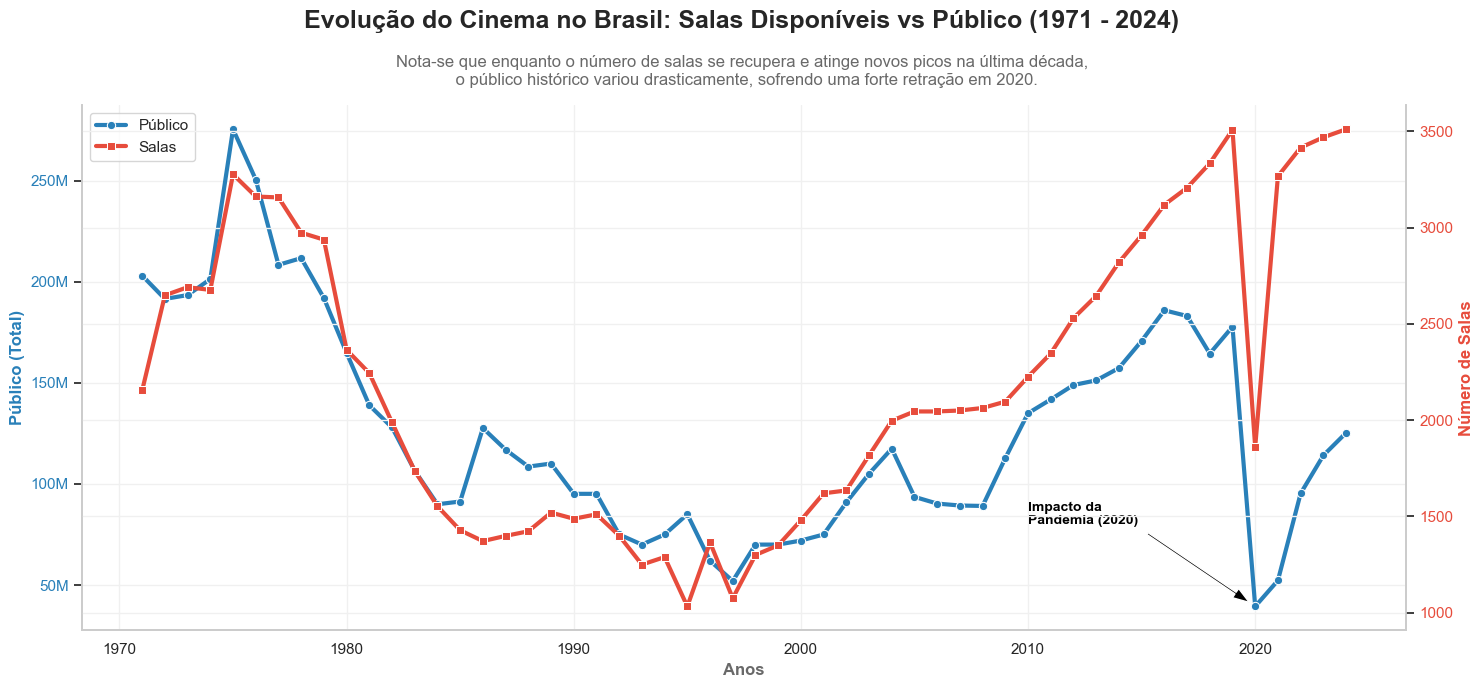

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", 'grid.color': '#f0f0f0'})

fig, ax1 = plt.subplots(figsize=(15, 7))

color1 = '#2980b9' 
color2 = '#e74c3c' 

ax1.set_xlabel('Anos', fontsize=12, fontweight='bold', color='dimgrey')

sala_publico.set_index('Ano', inplace=True)

ax1.set_ylabel('Público (Total)', fontsize=12, fontweight='bold', color=color1)
sns.lineplot(data=sala_publico, x=sala_publico.index, y='Público', color=color1, linewidth=3, marker='o', label='Público', ax=ax1)
ax1.tick_params(axis='y', labelcolor=color1)

def formatar_milhoes(x, pos):
    return f'{x * 1e-6:,.0f}M'
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_milhoes))

ax2 = ax1.twinx()  
ax2.set_ylabel('Número de Salas', fontsize=12, fontweight='bold', color=color2)
sns.lineplot(data=sala_publico, x=sala_publico.index, y='Salas', color=color2, linewidth=3, marker='s', label='Salas', ax=ax2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.annotate('Impacto da\nPandemia (2020)', 
             xy=(2020, 39437397), 
             xytext=(2010, 80000000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', color='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11)
ax2.get_legend().remove()

plt.suptitle('Evolução do Cinema no Brasil: Salas Disponíveis vs Público (1971 - 2024)', 
             fontsize=18, fontweight='bold', y=0.98, x=0.5)
plt.title('Nota-se que enquanto o número de salas se recupera e atinge novos picos na última década, \n o público histórico variou drasticamente, sofrendo uma forte retração em 2020.', 
          fontsize=12, color='dimgrey', pad=15)

sns.despine(ax=ax1, right=False, left=False, top=True)
sns.despine(ax=ax2, right=False, left=False, top=True)

plt.tight_layout()
plt.show()

(Anos 1970 - 1980)

No início da série histórica, vemos um alto volume de espectadores e de salas. Esse período reflete o auge dos cinemas de rua, que eram opções de lazer baratas e acessíveis. O cinema nacional também tinha grande força com o apoio da Embrafilme e o fenômeno de bilheteria das pornochanchadas.

A curva começa a cair pela grave crise econômica que reduziu o poder de compra da população, somada à popularização da televisão em cores e à chegada do videocassete (VHS) nos lares brasileiros, que tiraram o público das ruas.

(Anos 1990)

A década de 1990 marca o ponto mais baixo de ambas as linhas. Historicamente, isso coincide com o Governo Collor (1990), que extinguiu a Embrafilme e desestruturou a indústria audiovisual brasileira.

(Anos 2000 - 2019)

A partir dos anos 2000, a linha de salas volta a subir de forma constante, chegando a ultrapassar os picos da década de 70. Essa recuperação é impulsionada pela chegada dos grandes complexos de cinema (multiplex) para dentro dos shopping centers.

O público também volta a crescer, impulsionado pelas leis de incentivo (Lei do Audiovisual), a criação da ANCINE e o domínio global dos blockbusters de Hollywood.

Note que, mesmo com um número recorde de salas nos anos 2010, o público total não atinge os mesmos picos da década de 70. Isso ocorre porque o cinema de shopping se tornou um produto mais elitizado e caro. Há mais salas, porém concentradas em áreas de maior renda, o que limita o volume total de ingressos per capita.

(2020 - 2024)

O gráfico mostra a queda mais abrupta da história em 2020, justificada pelas medidas de isolamento social da pandemia de COVID-19, que forçaram o fechamento completo das salas por meses.

A partir de 2021, vemos uma leve tentativa de recuperação do público. No entanto, o retorno aos níveis pré-pandemia tem sido contido pela consolidação das plataformas de streaming. O público se acostumou a consumir conteúdo em casa, reservando a ida ao cinema (agora ainda mais custosa) apenas para eventos cinematográficos.

--- 

#### **Como o processo de modernização e a transição para o modelo de complexos no século XXI influenciaram o desaparecimento dos tradicionais cinemas de rua no Brasil?**

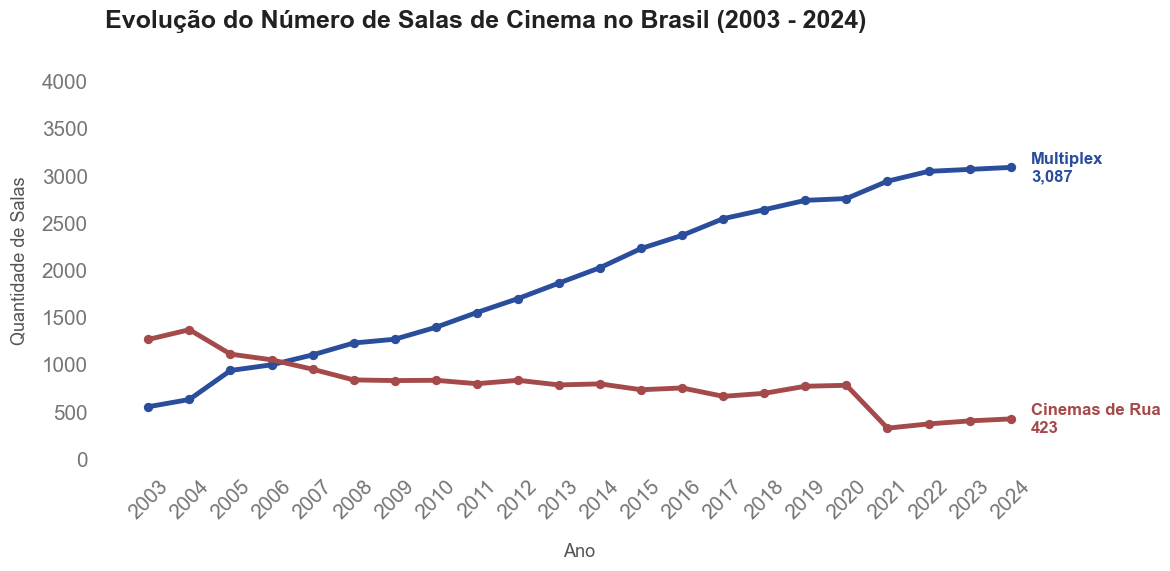

In [ ]:
sns.set_theme(style="white", context="talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(12, 6))

color_multiplex = '#2a4d9c' 
color_rua = '#a54a4a'       

sns.lineplot(data=multiplex, x='Ano', y='Total_Salas', 
             color=color_multiplex, linewidth=3.5, ax=ax)
sns.lineplot(data=cinema_rua, x='Ano', y='Qtd de salas dos cinemas de rua', 
             color=color_rua, linewidth=3.5, ax=ax)

sns.scatterplot(data=multiplex, x='Ano', y='Total_Salas', 
                color=color_multiplex, s=60, edgecolors='white', linewidth=1, ax=ax)
sns.scatterplot(data=cinema_rua, x='Ano', y='Qtd de salas dos cinemas de rua', 
                color=color_rua, s=60, edgecolors='white', linewidth=1, ax=ax)

ax.set_title('Evolução do Número de Salas de Cinema no Brasil (2003 - 2024)', 
             fontsize=18, fontweight='bold', color='#212121', loc='left', pad=25)

ax.set_ylabel('Quantidade de Salas', fontsize=13, color='#555555', labelpad=10)
ax.set_xlabel('Ano', fontsize=13, color='#555555', labelpad=15)

ax.set_xticks(multiplex['Ano'])
plt.xticks(rotation=45, color='#757575')
plt.yticks(color='#757575') 

ax.set_ylim(0, 4200)

final_val_multiplex = multiplex.iloc[-1]['Total_Salas']
final_ano_multiplex = multiplex.iloc[-1]['Ano']
ax.text(final_ano_multiplex + 0.5, final_val_multiplex, 
        f'Multiplex\n{final_val_multiplex:,}',
        color=color_multiplex, fontweight='bold', fontsize=12, va='center', ha='left')

final_val_rua = cinema_rua.iloc[-1]['Qtd de salas dos cinemas de rua']
final_ano_rua = cinema_rua.iloc[-1]['Ano']
ax.text(final_ano_rua + 0.5, final_val_rua, 
        f'Cinemas de Rua\n{final_val_rua:,}', 
        color=color_rua, fontweight='bold', fontsize=12, va='center', ha='left')

sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

plt.tight_layout()

plt.show()

C:\Users\kaiol\AppData\Local\Temp\ipykernel_22460\3709859556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


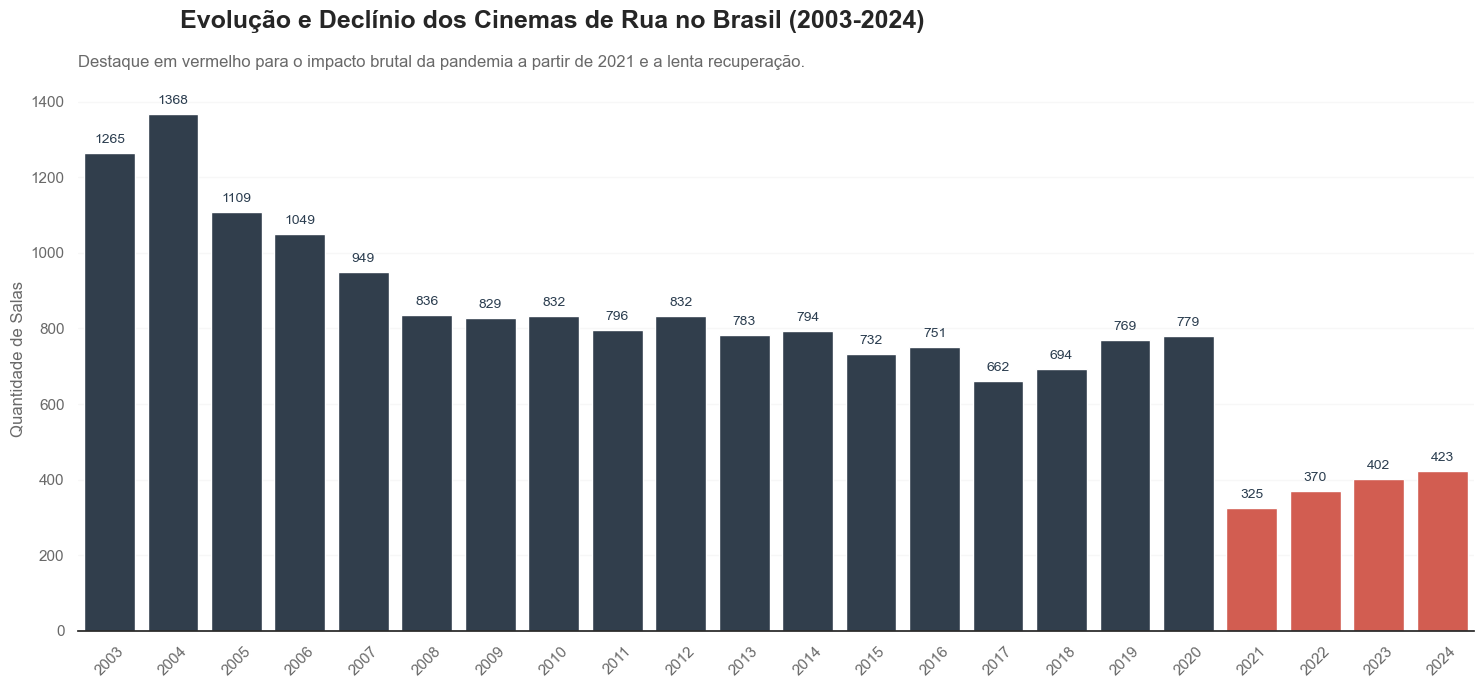

In [ ]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

fig, ax = plt.subplots(figsize=(15, 7))

colors = ['#e74c3c' if ano >= 2021 else '#2c3e50' for ano in cinema_rua['Ano']]

sns.barplot(
    data=cinema_rua, 
    x='Ano', 
    y='Qtd de salas dos cinemas de rua', 
    palette=colors,
    ax=ax
)

plt.suptitle('Evolução e Declínio dos Cinemas de Rua no Brasil (2003-2024)', 
             fontsize=18, fontweight='bold', x=0.125, ha='left')
plt.title('Destaque em vermelho para o impacto brutal da pandemia a partir de 2021 e a lenta recuperação.', 
          fontsize=12, loc='left', color='dimgrey', pad=15)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='#2c3e50', xytext=(0, 5), 
                textcoords='offset points')

plt.xlabel('') 
plt.ylabel('Quantidade de Salas', fontsize=12, color='dimgrey')
plt.xticks(rotation=45, color='dimgrey', fontsize=11)
plt.yticks(color='dimgrey', fontsize=11)

ax.grid(axis='y', linestyle='-', alpha=0.15)

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

(2003 - 2006)

O primeiro gráfico mostra que, em 2003, os cinemas de rua ainda eram maioria no país. Contudo, entre 2005 e 2006, ocorre o cruzamento das linhas: os complexos Multiplex ultrapassam as salas de rua.

Esse período reflete o boom da construção de shopping centers no Brasil. A classe média no país aumentou e passaram a buscar opções de lazer que oferecessem mais segurança e conforto. As redes Multiplex, em sua maior parte estrangeiras ou grandes grupos nacionais, trouxeram o conceito de várias salas em um mesmo local, oferecendo maior variedade de horários e filmes, algo com o qual o cinema de rua de sala única ou dupla não conseguia competir.

(2007 - 2019)

A partir de 2006, o gráfico 1 mostra uma ascensão vertiginosa dos Multiplex, enquanto o gráfico 2 detalha o declinio dos cinemas de rua, que caem de cerca de 1.000 salas para a faixa das 700.

A maioria dos grandes cinemas de rua ficava nos centros históricos das capitais e grandes cidades. Com o aumento da violência urbana e a degradação dessas áreas, o público migrou para os shoppings.

Antigos prédios de cinema, localizados em áreas valorizadas ou comerciais, tornaram-se caros demais para manter. Muitos foram vendidos e transformados em templos religiosos, estacionamentos, farmácias ou supermercados.

A transição da película de 35mm para a projeção digital foi um dos maiores golpes para os cinemas independentes. Os projetores digitais custavam dezenas de milhares de dólares. Enquanto as redes de shopping tinham capital para a conversão tecnológica, muitos cinemas de rua de bairro ou de cidades do interior simplesmente fecharam as portas por não conseguirem pagar pela modernização.

(2020 - 2021)

O segundo gráfico destaca em vermelho o período mais dramático da série histórica: a queda de 779 salas em 2020 para apenas 325 em 2021.

A pandemia de COVID-19 forçou o fechamento de espaços culturais por meses. Enquanto as gigantes redes de Multiplex possuíam lastro financeiro, acesso a linhas de crédito maiores e o poder de negociação com os shoppings, os cinemas de rua, frequentemente geridos por pequenas empresas, associações culturais ou famílias, não suportaram os meses sem bilheteria e faliram definitivamente.

(2022 - 2024)

O final do segundo gráfico e com o terceiro percebe-se uma leve, porém constante, tendência de alta, saindo do fundo do poço de 325 salas para 423 salas em 2024, com um crescimento proporcional em relação com o multiplex de 80%. Essa recuperação tímida não indica um retorno ao auge dos cinemas de rua, mas sim uma reinvenção do modelo.

A injeção de recursos emergenciais e de fomento cultural (como a Lei Aldir Blanc e, posteriormente, a Lei Paulo Gustavo) foi fundamental para reabrir e manter espaços independentes.

Os cinemas de rua que sobrevivem ou que estão abrindo hoje raramente competem com os blockbusters da Marvel exibidos nos shoppings. Eles se reposicionaram como "cinemas de arte" ou espaços culturais. Atraem um público cinéfilo em busca de filmes independentes, festivais, produções nacionais, além de oferecerem cafés, debates e uma experiência mais intimista e charmosa, contrastando com a padronização dos shoppings.

---

#### **De que maneira a relação de "habitantes por sala" e "ingressos per capita" evidencia a desigualdade regional e demográfica no acesso à infraestrutura de cinema no Brasil em 2024?**

In [1440]:
df_ingressos = pd.read_csv('dados/ingresso_per_capita.csv')
df_habitantes = pd.read_csv('dados/habitantes_por_sala.csv')

Definimos os nomes dos estados do dataframe de ingressos per capita sem acentuações e em maiúsculo. Fizemos isso para padronizar essa coluna com a do dataframe de habitantes por sala.

In [1441]:
substituicoes = {"í": "i", "ã": "a", "á": "a", "ô": "o", "Ô": "O", "Í": "I", "Ã": "A", "Á": "A"}

df_ingressos['UF'] = df_ingressos['UF'].replace(substituicoes, regex=True)
df_ingressos['UF'] = df_ingressos['UF'].str.upper()

df_ingressos

,UF,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ACRE,0.08,0.05,0.08,0.10,0.05,0.08,0.11,0.17,0.51,...,0.59,0.62,0.65,0.55,0.61,0.14,0.25,0.32,0.33,0.36
1,ALAGOAS,0.16,0.13,0.10,0.09,0.09,0.14,0.22,0.26,0.34,...,0.50,0.52,0.52,0.46,0.49,0.10,0.14,0.33,0.41,0.43
2,AMAPA,0.26,0.21,0.22,0.26,0.26,0.34,0.29,0.28,0.28,...,0.54,0.81,0.86,0.75,0.77,0.16,0.24,0.47,0.55,0.58
3,AMAZONAS,0.47,0.38,0.42,0.41,0.46,0.55,0.77,0.91,0.90,...,0.96,1.01,0.97,0.89,0.87,0.20,0.21,0.39,0.53,0.54
4,BAHIA,0.32,0.22,0.19,0.18,0.23,0.30,0.39,0.41,0.41,...,0.40,0.45,0.42,0.40,0.42,0.10,0.11,0.23,0.26,0.32
5,CEARA,0.28,0.24,0.20,0.21,0.19,0.29,0.36,0.36,0.37,...,0.53,0.62,0.63,0.54,0.57,0.14,0.18,0.32,0.42,0.47
6,DISTRITO FEDERAL,2.03,1.23,1.07,1.26,1.43,1.64,1.96,2.02,1.72,...,1.98,2.10,1.85,1.68,1.79,0.41,0.51,0.93,1.11,1.27
7,ESPIRITO SANTO,0.57,0.43,0.39,0.41,0.45,0.59,0.65,0.64,0.67,...,0.82,0.91,0.80,0.75,0.82,0.20,0.25,0.41,0.48,0.54
8,GOIAS,0.49,0.37,0.30,0.34,0.39,0.54,0.61,0.64,0.70,...,0.66,0.73,0.74,0.65,0.66,0.15,0.19,0.39,0.45,0.47
9,MARANHAO,0.17,0.13,0.11,0.14,0.13,0.15,0.18,0.21,0.21,...,0.32,0.36,0.33,0.33,0.32,0.08,0.09,0.19,0.21,0.23


Em habitantes por sala selecionamos apenas os anos acima de 2003, pois o dataframe de ingressos per capita só cobre esse escopo de tempo.

In [1442]:
df_habitantes = df_habitantes.rename(columns={'estado': 'UF'})
df_habitantes = df_habitantes.drop(columns=['2002', '2003'])
df_habitantes

,UF,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ACRE,315164,334868,223245,218462,226691,230377,244264,106627,108398,...,160703,163337,118517,124181,125991,127781,129554,124652,125226,125804
1,ALAGOAS,496818,502652,502652,433890,625511,631222,312092,224527,226105,...,115205,115826,116408,114580,115081,115570,129437,103819,103826,100628
2,AMAPA,91233,84941,99098,83902,87595,104435,111448,114052,87325,...,45099,52153,53181,55300,56382,57452,58508,53030,53275,53522
3,AMAZONAS,184631,146924,146924,107398,111370,109464,84901,86302,94500,...,62513,63519,58052,56271,57564,58440,83725,71183,70676,67956
4,BAHIA,204210,222828,234158,210159,216456,187659,170993,187967,166769,...,178870,153504,147543,129339,114408,112260,123845,106556,105920,103850
5,CEARA,249268,224924,224924,227368,241444,208483,192001,198376,204905,...,106005,91466,89311,89858,83781,81302,90594,82549,82113,83186
6,DISTRITO FEDERAL,29637,34035,33648,26695,28413,28031,32037,33896,41953,...,33893,34221,34936,34192,34264,34718,37281,35148,37564,37285
7,ESPIRITO SANTO,79810,81152,92118,77946,76748,81098,78059,80615,76129,...,56955,55190,54275,54416,54306,54920,59544,58709,57409,56974
8,GOIAS,98362,102180,96895,75294,81181,80085,81136,76971,73274,...,67456,59784,57938,59665,61565,59778,64924,66067,61648,61769
9,MARANHAO,354206,381458,381458,319937,573231,578831,386452,332288,319729,...,156915,134012,112907,115241,115987,112930,145985,112872,125058,127472


Transformamos o formato de ambos os dataframes para long, pois isso facilita os cálculos em cada ano na matriz de correlação e a plotagem do gráfico.

In [1443]:
df_ingressos = df_ingressos.melt(
    id_vars=['UF'],
    var_name='ano',
    value_name='ingressos_per_capta'
)

df_habitantes = df_habitantes.melt(
    id_vars=['UF'],
    var_name='ano',
    value_name='habitantes_por_sala'
)

Convertemos o tipo da coluna ano em todos os dataframes para inteiro.

In [1444]:
df_ingressos['ano'] = pd.to_numeric(df_ingressos['ano'], errors='coerce')
df_habitantes['ano'] = pd.to_numeric(df_habitantes['ano'], errors='coerce')

Unimos os dataframes.

In [1445]:
df = pd.merge(df_ingressos, df_habitantes, 
              on=['UF', 'ano'], 
              how='inner')
df

,UF,ano,ingressos_per_capta,habitantes_por_sala
0,ACRE,2004,0.08,315164
1,ALAGOAS,2004,0.16,496818
2,AMAPA,2004,0.26,91233
3,AMAZONAS,2004,0.47,184631
4,BAHIA,2004,0.32,204210
...,...,...,...,...
562,RORAIMA,2024,0.62,55138
563,SANTA CATARINA,2024,0.61,53723
564,SAO PAULO,2024,0.91,41306
565,SERGIPE,2024,0.47,65459


Construção da matriz de correlação.

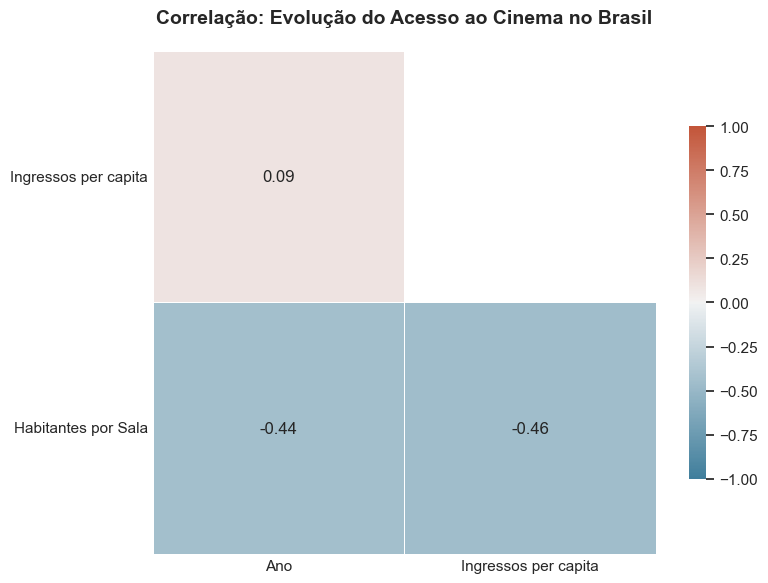

In [1446]:
import numpy as np

colunas_interesse = ['ano', 'ingressos_per_capta', 'habitantes_por_sala']
df_plot = df[colunas_interesse].copy()

df_plot.columns = ['Ano', 'Ingressos per capita', 'Habitantes por Sala']

matriz_correlacao = df_plot.corr()
mascara_completa = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

matriz_correlacao_plot = matriz_correlacao.iloc[1:, :-1]
mascara_plot = mascara_completa[1:, :-1]

plt.figure(figsize=(8, 6))

paleta_cores = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    matriz_correlacao_plot,   
    mask=mascara_plot,         
    cmap=paleta_cores,          
    annot=True,                 
    fmt=".2f",                  
    vmin=-1, vmax=1, center=0,  
    square=True,                
    linewidths=.5,              
    cbar_kws={"shrink": .7}    
)

plt.title('Correlação: Evolução do Acesso ao Cinema no Brasil', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=0)          
plt.yticks(rotation=0)

plt.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

Ingressos per capita vs. Habitantes por Sala:

Quando o número de habitantes por sala diminui (ou seja, há mais salas de cinema disponíveis para a população), o número de ingressos per capita tende a aumentar. Isso sugere que a maior oferta e proximidade de salas de cinema (melhor acesso à infraestrutura) está razoavelmente associada a uma maior frequência do público aos cinemas.

Ano vs. Habitantes por Sala:

Com o passar dos anos, o número de habitantes por sala tendeu a diminuir levemente. Isso indica uma leve tendência histórica de melhora na infraestrutura, sugerindo que o número de salas de cinema cresceu em um ritmo ligeiramente superior ao crescimento da população ao longo do período analisado.

Ano vs. Ingressos per capita:

A simples passagem do tempo não explica o aumento ou a diminuição da venda de ingressos por pessoa. O fato de estarmos em um ano mais recente ou mais antigo não tem relação direta forte com as pessoas irem mais ou menos ao cinema. Outros fatores como a disponibilidade de salas mencionada acima, economia, qualidade dos filmes, ou concorrência com o streaming, afetam muito mais isso do que apenas a passagem do tempo.

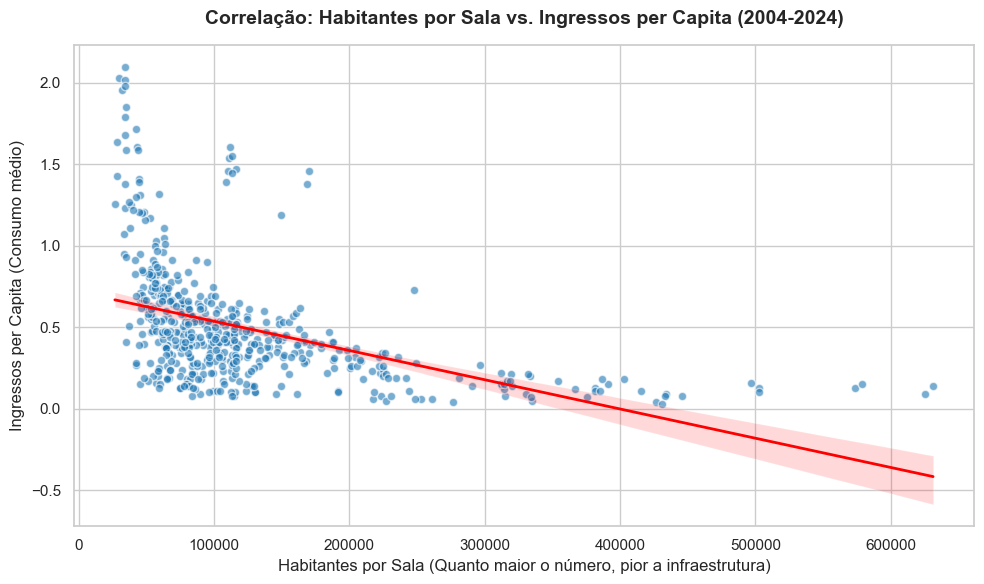

In [1447]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=df, 
    x='habitantes_por_sala', 
    y='ingressos_per_capta',
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4', 'edgecolor': 'w'}, 
    line_kws={'color': 'red', 'linewidth': 2} 
)

plt.title('Correlação: Habitantes por Sala vs. Ingressos per Capita (2004-2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Habitantes por Sala (Quanto maior o número, pior a infraestrutura)', fontsize=12)
plt.ylabel('Ingressos per Capita (Consumo médio)', fontsize=12)

plt.tight_layout()
plt.show()

O gráfico de dispersão apresenta uma linha de tendência vermelha que aponta para baixo, evidenciando uma correlação inversamente proporcional. Quanto maior o número de habitantes por sala, menor é a venda de ingressos per capita.

Esse comportamento desmistifica a ideia de que o baixo consumo em certas regiões ocorre por falta de hábito ou interesse do público. Os dados provam que existe uma barreira estrutural e logística. As pessoas não vão ao cinema porque simplesmente não há cinemas acessíveis perto delas. Onde a oferta de salas é melhor, o consumo dispara. Onde há superlotação potencial, o consumo é sufocado.

Coletamos os dados de sala por região para fazer uma amostragem das desigualdades do acesso ao cinema em diferentes localidades do país.

Transformamos o formato da tabela para long, isso facilita a construção de gráficos. Além disso, convertemos os valores numéricos da tabela para float.

In [1448]:
sala_per_regiao = pd.read_csv('dados/sala_por_regiao.csv')

df_long = sala_per_regiao.melt(id_vars='região', var_name='ano', value_name='salas')

df_long['ano'].dropna()

df_long['ano'] = pd.to_numeric(df_long['ano'], errors='coerce')

if df_long['salas'].dtype == 'object':
    df_long['salas'] = df_long['salas'].str.replace('.', '', regex=True).astype(int)

df_long['salas'] = pd.to_numeric(df_long['salas'], errors='coerce')
df_long

,região,ano,salas
0,Centro-Oeste,2004,161
1,Nordeste,2004,218
2,Norte,2004,49
3,Sudeste,2004,1025
4,Sul,2004,266
...,...,...,...
100,Centro-Oeste,2024,288
101,Nordeste,2024,598
102,Norte,2024,227
103,Sudeste,2024,1839


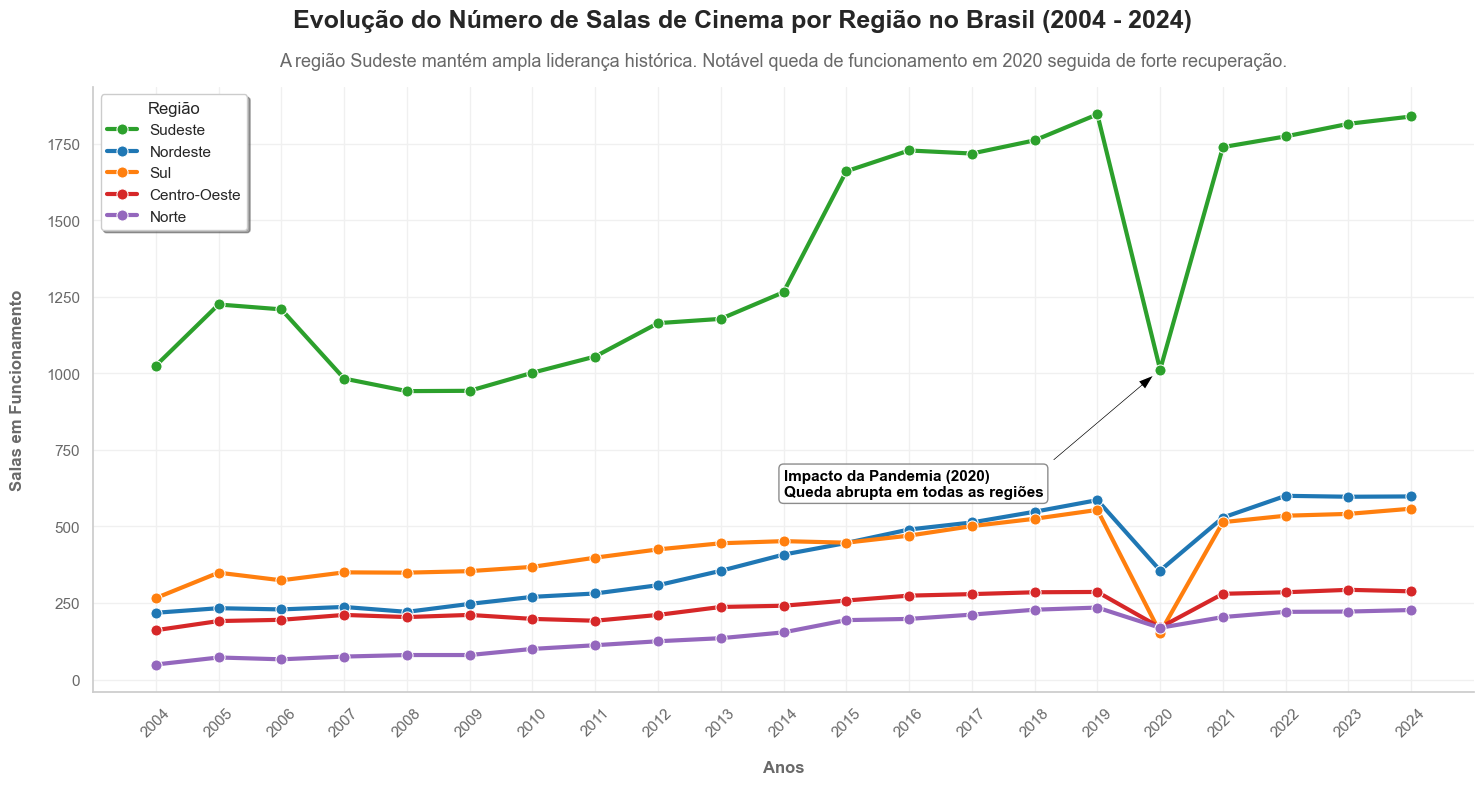

In [1449]:
ordem_regioes = df_long[df_long['ano'] == 2024].sort_values('salas', ascending=False)['região'].tolist()

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", 'grid.color': '#f0f0f0'})

fig, ax = plt.subplots(figsize=(15, 8))

paleta = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']

sns.lineplot(
    data=df_long, 
    x='ano', 
    y='salas', 
    hue='região', 
    hue_order=ordem_regioes,
    palette=paleta, 
    linewidth=3, 
    marker='o',
    markersize=8,
    ax=ax
)

ax.set_xlabel('Anos', fontsize=12, fontweight='bold', color='dimgrey', labelpad=15)
ax.set_ylabel('Salas em Funcionamento', fontsize=12, fontweight='bold', color='dimgrey', labelpad=15)

plt.xticks(df_long['ano'].unique(), rotation=45, color='dimgrey')
plt.yticks(color='dimgrey')

ax.annotate('Impacto da Pandemia (2020)\nQueda abrupta em todas as regiões', 
             xy=(2020, 1012),
             xytext=(2014, 600),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', color='black',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9))

plt.legend(title='Região', title_fontsize='12', fontsize='11', loc='upper left', frameon=True, shadow=True)

plt.suptitle('Evolução do Número de Salas de Cinema por Região no Brasil (2004 - 2024)', 
             fontsize=18, fontweight='bold', y=0.98, x=0.5)
plt.title('A região Sudeste mantém ampla liderança histórica. Notável queda de funcionamento em 2020 seguida de forte recuperação.', 
          fontsize=13, color='dimgrey', pad=15)

sns.despine(right=True, top=True)

plt.tight_layout()
plt.show()

A região Sudeste possui uma quantidade de salas de cinema absurdamente maior do que qualquer outra região do país. Durante todo o período, ela se mantém no topo de forma isolada, chegando a ter quase o triplo de salas da segunda colocada nos anos mais recentes. Isso se dá por uma forte concentração de investimentos em cultura e infraestrutura de entretenimento no Sudeste, refletindo também a concentração populacional e de renda do país.

Se observarmos o período de 2004 a meados de 2015, a região Sul era historicamente a segunda com mais salas. No entanto, por volta de 2017/2018, a região Nordeste ultrapassou o Sul e se consolidou como o segundo maior mercado exibidor do país. Isso indica um período de forte expansão de shoppings e complexos de cinema no Nordeste na última década, descentralizando um pouco o mercado fora do eixo Sul-Sudeste.

As regiões Norte e Centro-Oeste têm os menores números absolutos de salas. O Norte, especificamente, tem a linha mais baixa e com o crescimento mais lento de todas, evidenciando um grande desafio geográfico e econômico para a expansão do acesso ao cinema na região.

In [1451]:
habitantes_por_sala = pd.read_csv('dados/habitantes_por_sala.csv')
habitantes_por_sala.sort_values(by='2024', ascending=False)

,UF,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
9,MARANHAO,706434,332440,354206,381458,381458,319937,573231,578831,386452,...,156915,134012,112907,115241,115987,112930,145985,112872,125058,127472
0,ACRE,278763,278763,315164,334868,223245,218462,226691,230377,244264,...,160703,163337,118517,124181,125991,127781,129554,124652,125226,125804
17,PIAUI,284328,315920,330807,375861,334098,433205,445671,314533,311902,...,133501,139660,123818,108818,96271,96514,149513,115760,116065,116402
13,PARA,476331,412820,402952,290441,366873,415622,385342,391106,281040,...,127585,127136,126767,101245,101210,102244,123621,112764,113370,114004
19,RIO GRANDE DO NORTE,462797,277678,296211,333676,200206,200916,221888,224110,166744,...,111038,112097,113129,108965,113124,107096,118697,100822,101067,107690
4,BAHIA,242042,210810,204210,222828,234158,210159,216456,187659,170993,...,178870,153504,147543,129339,114408,112260,123845,106556,105920,103850
1,ALAGOAS,470437,470437,496818,502652,502652,433890,625511,631222,312092,...,115205,115826,116408,114580,115081,115570,129437,103819,103826,100628
14,PARAIBA,229588,156538,137244,138303,149829,151725,187130,188499,188342,...,116829,111095,108799,99349,89292,89762,104100,97763,95918,96396
5,CEARA,337757,239699,249268,224924,224924,227368,241444,208483,192001,...,106005,91466,89311,89858,83781,81302,90594,82549,82113,83186
11,MATO GROSSO DO SUL,122235,138533,123928,125804,113223,133283,137415,138853,144079,...,94687,99348,100487,101779,89645,80268,91587,81554,82229,82911


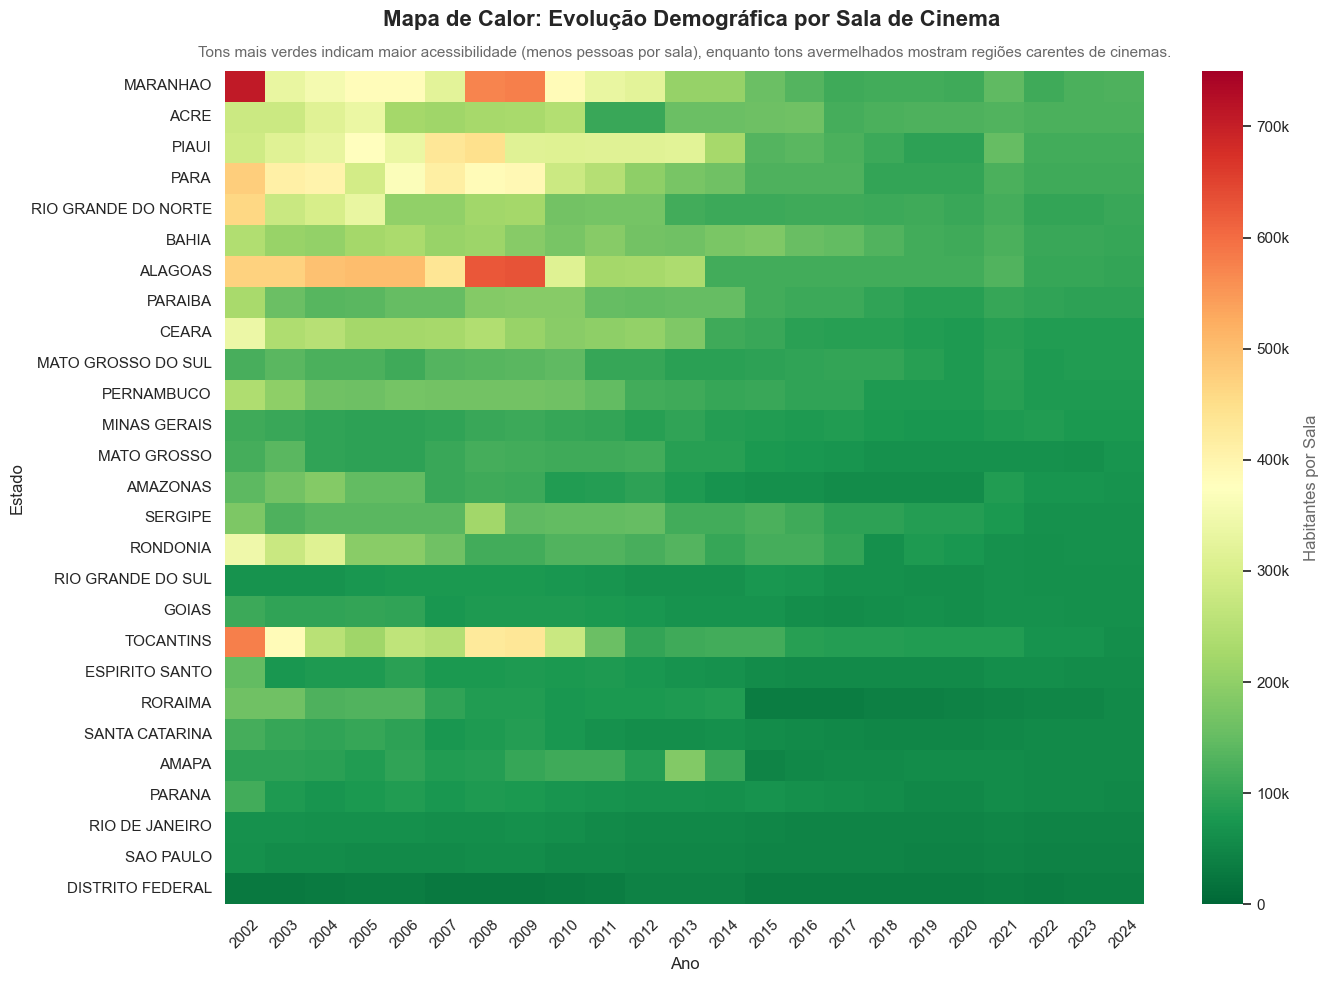

In [1452]:
fig, ax = plt.subplots(figsize=(14, 10))

df_heatmap = habitantes_por_sala.set_index('UF')
df_heatmap = df_heatmap.sort_values(by='2024', ascending=False)

sns.heatmap(df_heatmap, cmap='RdYlGn_r', ax=ax, vmin=0, vmax=750000)

cbar = ax.collections[0].colorbar
cbar.set_label('Habitantes por Sala', size=12, color='dimgrey', labelpad=10)

marcacoes = [0, 100000, 200000, 300000, 400000, 500000, 600000, 700000]
textos = ['0', '100k', '200k', '300k', '400k', '500k', '600k', '700k']

cbar.set_ticks(marcacoes)
cbar.set_ticklabels(textos)

plt.suptitle('Mapa de Calor: Evolução Demográfica por Sala de Cinema', fontsize=16, fontweight='bold')
ax.set_title('Tons mais verdes indicam maior acessibilidade (menos pessoas por sala), enquanto tons avermelhados mostram regiões carentes de cinemas.', fontsize=11, color='dimgrey', pad=10)

ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Estado', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

O padrão mais óbvio é que o gráfico "esverdeia" da esquerda (2002) para a direita (2024). Isso significa que a proporção de habitantes por sala caiu em praticamente todo o território nacional. Ou seja, a expansão das salas de cinema ocorreu em um ritmo mais acelerado do que o crescimento populacional nas últimas duas décadas, melhorando o acesso geral.

Se olharmos para a coluna da esquerda (2002-2006), veremos uma clara divisão. Os estados listados no topo estão em tons de amarelo, laranja e vermelho, indicando uma carência severa de infraestrutura, todos eles estão localizados na região norte e nordeste. Em contraste, os estados mais abaixo do gráfico já eram verde-escuros desde 2002. Eles sempre tiveram uma boa oferta de cinemas proporcional às suas populações.

Os blocos em vermelho escuro indicam momentos em que a situação estava crítica. Por exemplo, o Maranhão em 2002 e Alagoas em 2008/2009 chegaram a ter mais de 600 mil a 700 mil habitantes para uma única sala de cinema. Isso geralmente ocorre quando cinemas de rua antigos fecham as portas antes que os novos complexos de shopping sejam inaugurados no estado.

A partir de 2014/2015, os tons amarelados praticamente desaparecem do mapa. Isso reflete diretamente aquele cruzamento que vimos no gráfico de linhas anterior, onde a região Nordeste começou a receber investimentos pesados e ultrapassou o Sul em número absoluto de salas. Hoje, embora SP e DF ainda possuam mais acesso, a disparidade para estados como Ceará, Bahia e Pernambuco é muito menor do que era há 20 anos.

---

### **Quais são os perfis de mercado identificados ao cruzar a infraestrutura de salas, a população e o consumo per capita?**

Extraimos apenas a primeira coluna do arquivo original e criamos um novo DataFrame chamado df, dando a essa coluna o nome de 'UF'.

Sobrescrevemos o dataframe original para manter apenas duas colunas: 'UF' e '2024'. Todas as outras colunas que existiam no CSV original são descartadas nesta seleção.

In [2]:
import pandas as pd

c:\Users\kaiol\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\kaiol\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
salas_por_estado = pd.read_csv('dados/sala_por_estado.csv')

df = pd.DataFrame(salas_por_estado.iloc[:, 0].values, columns=['UF'])

salas_por_estado = salas_por_estado[['UF', '2024']]
salas_por_estado

,UF,2024
0,ACRE,7
1,ALAGOAS,32
2,AMAPA,15
3,AMAZONAS,63
4,BAHIA,143
5,CEARA,111
6,DISTRITO FEDERAL,80
7,ESPIRITO SANTO,72
8,GOIAS,119
9,MARANHAO,55


Assim como no exemplo anterior, ele seleciona apenas as colunas 'UF' e '2024', descartando qualquer outro ano ou dado que estivesse no arquivo original. A variável é sobrescrita e atualizada para manter apenas essas duas colunas.

In [4]:
habitantes_por_sala = pd.read_csv('dados/habitantes_por_sala.csv')
habitantes_por_sala = habitantes_por_sala[['UF', '2024']]
habitantes_por_sala

,UF,2024
0,ACRE,125804
1,ALAGOAS,100628
2,AMAPA,53522
3,AMAZONAS,67956
4,BAHIA,103850
5,CEARA,83186
6,DISTRITO FEDERAL,37285
7,ESPIRITO SANTO,56974
8,GOIAS,61769
9,MARANHAO,127472


Assim como nos exemplos anteriores, ele lê o dataframe de ingressos per capita e logo em seguida filtra a tabela para manter apenas as colunas 'UF' e '2024'.

O objetivo do dicionário substituições é mapear letras com acento para as suas versões sem acento.

O comando iloc[:, 0] seleciona todas as linhas da coluna UF.

A função .replace() usa o dicionário criado acima para procurar qualquer letra com acento nos nomes dos estados e trocá-la pela versão sem acento. O regex=True permite que a substituição seja feita em partes da palavra, e não apenas se a palavra inteira for igual à chave do dicionário. Novamente atuando na primeira coluna, o comando .str.upper() pega todos os textos e os transforma em letras maiúsculas.

Renomeamos as colunas do DataFrame. A diferença aqui é que o ano 2024 agora foi passado como um número inteiro, isso pode facilitar cruzamentos de dados ou manipulações futuras.

In [5]:
ingressos_per_capita = pd.read_csv('dados/ingresso_per_capita.csv')
ingressos_per_capita = ingressos_per_capita[['UF', '2024']]

substituicoes = {"í": "i", "ã": "a", "á": "a", "ô": "o", "Ô": "O", "Í": "I", "Ã": "A", "Á": "A"}

ingressos_per_capita.iloc[:, 0] = ingressos_per_capita.iloc[:, 0].replace(substituicoes, regex=True)
ingressos_per_capita.iloc[:, 0] = ingressos_per_capita.iloc[:, 0].str.upper()
ingressos_per_capita.columns = ['UF', 2024]
ingressos_per_capita

,UF,2024
0,ACRE,0.36
1,ALAGOAS,0.43
2,AMAPA,0.58
3,AMAZONAS,0.54
4,BAHIA,0.32
5,CEARA,0.47
6,DISTRITO FEDERAL,1.27
7,ESPIRITO SANTO,0.54
8,GOIAS,0.47
9,MARANHAO,0.23


Unimos as colunas dos três dataframes no dataframe vazio que criamos inicialmente somente com a coluna UF. Essa união ocorre por meio do meio, usando a coluna UF.

In [6]:
dataframes = [salas_por_estado, habitantes_por_sala, ingressos_per_capita]

for dfs in dataframes:
    df = pd.merge(df, dfs, on='UF', how='right')

df.columns = ['Estado', 'Salas Totais', 'Habitantes por Sala', 'Ingressos per Capita']
df

,Estado,Salas Totais,Habitantes por Sala,Ingressos per Capita
0,ACRE,7,125804,0.36
1,ALAGOAS,32,100628,0.43
2,AMAPA,15,53522,0.58
3,AMAZONAS,63,67956,0.54
4,BAHIA,143,103850,0.32
5,CEARA,111,83186,0.47
6,DISTRITO FEDERAL,80,37285,1.27
7,ESPIRITO SANTO,72,56974,0.54
8,GOIAS,119,61769,0.47
9,MARANHAO,55,127472,0.23


Usamos o StandardScaler para converter todas as colunas para a mesma escala proporcional. Isso é importante para que o algoritmo de agrupamento trabalhe com dados na mesma proporção.

In [7]:
from sklearn.preprocessing import StandardScaler

features = ['Salas Totais', 'Habitantes por Sala', 'Ingressos per Capita']

scaler = StandardScaler()

df_padronizado = scaler.fit_transform(df[features])
df_padronizado

array([[-0.5818115 ,  1.90101426, -0.63630019],
       [-0.46355713,  0.92935073, -0.32393464],
       [-0.5439701 , -0.88869751,  0.3454201 ],
       [-0.31692171, -0.33161968,  0.1669255 ],
       [ 0.06149227,  1.05370329, -0.81479479],
       [-0.08987332,  0.25617964, -0.14544004],
       [-0.23650874, -1.51536182,  3.42445192],
       [-0.27435014, -0.75546814,  0.1669255 ],
       [-0.05203192, -0.57040591, -0.14544004],
       [-0.35476311,  1.96539045, -1.21640763],
       [-0.35949328, -0.21243883, -0.36855829],
       [-0.4493666 ,  0.24556606, -0.27931099],
       [ 0.67168482,  0.07115601, -0.41318194],
       [-0.25542944,  1.44559523, -0.99328938],
       [-0.4115252 ,  0.76601739, -0.81479479],
       [ 0.47774765, -0.97873925,  0.3454201 ],
       [-0.0567621 ,  0.16559757,  0.0776782 ],
       [-0.47774765,  1.53814564, -0.94866573],
       [ 1.19200404, -1.21459228,  1.99649513],
       [-0.46355713,  1.20190745, -0.32393464],
       [ 0.22231821, -0.50568238, -0.100

Aplicamos um algoritmo K-Means para agrupar dados parecidos. Ele vai tentar descobrir quais estados brasileiros têm características semelhantes com base nas salas de cinema, habitantes por sala e frequência em que a população vai ao cinema, e juntá-los em grupos.

Nesse algoritmo precisamos dizer a ele quantos grupos ele deve criar. Como não sabemos qual é o número ideal de grupos para os dados dos estados, usamos o Método do Cotovelo.

Inicialmente criamos uma lista vazia chamada inercia para guardar os resultados dos testes que o algoritmo fará a seguir. 

Criamos um loop para testar a criação de grupos. Ele tenta dividir os dados em 1 grupo, depois em 2, 3, e assim por diante, até 9 grupos. Para cada teste, ele usa o df_padronizado, aquela tabela com os números na mesma escala matemática que vimos antes. A cada tentativa, ele calcula a inércia, ou seja, o quão espalhados estão os dados dentro de um mesmo grupo. Quanto menor a inércia, mais compactos e parecidos são os estados dentro daquele grupo. Armazenamos essas inercias em uma lista.

O restante do código apenas pega os números calculados no passo anterior e desenha o gráfico de linha do "cotovelo".

c:\Users\kaiol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kaiol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kaiol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kaiol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

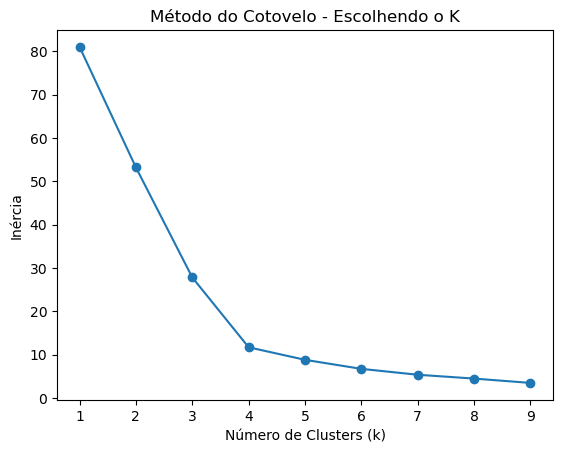

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_padronizado)
    inercia.append(kmeans.inertia_)

# Plota o gráfico para ver onde o "cotovelo" se forma
plt.plot(range(1, 10), inercia, marker='o')
plt.title('Método do Cotovelo - Escolhendo o K')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()

Definimos a separação dos dados em quatro grupos.

A função .fit_predict() estuda os dados padronizados e decide em qual dos 4 grupos cada estado se encaixa. Em seguida, criamos uma nova coluna chamada 'Cluster' na tabela original e anota o número do grupo correspondente ao lado de cada estado.

A função .groupby junta todos os estados que receberam o mesmo número de grupo. O comando .mean() calcula a média das características, como habitante por sala, para os estados daquele grupo específico.

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_padronizado)

perfil_clusters = df.groupby('Cluster')[features].mean()
perfil_clusters

c:\Users\kaiol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Salas Totais,Habitantes por Sala,Ingressos per Capita
Cluster,,,
0,94.875,65680.625,0.48625
1,1113.000,41306.000,0.91000
2,52.125,111530.750,0.33250
3,231.000,41181.500,1.11000


Criamos um dicionário para dar nomes para cada número de grupo com base nas características deles.

O comando .map() pega a coluna antiga, que só tinha os números 0, 1, 2 e 3, olha para o dicionário que acabou de ser criado e faz a tradução. Ele guarda esse resultado em uma nova coluna chamada 'Nome_Cluster'. 

In [10]:
dicionario_clusters = {
    3: 'Elite de Consumo', # Alta frequência e melhor infraestrutura relativa.    
    2: 'Desertos de Tela (Baixíssimo Acesso)', # Carência severa de salas e baixo consumo.             
    0: 'Subatendido', # Baixa oferta para a população existente.
    1: 'Megacentro' # Concentração massiva de salas e infraestrutura.
}

df['Nome_Cluster'] = df['Cluster'].map(dicionario_clusters)

display(df.groupby('Nome_Cluster')[features].mean())

,Salas Totais,Habitantes por Sala,Ingressos per Capita
Nome_Cluster,,,
Desertos de Tela (Baixíssimo Acesso),52.125,111530.750,0.33250
Elite de Consumo,231.000,41181.500,1.11000
Megacentro,1113.000,41306.000,0.91000
Subatendido,94.875,65680.625,0.48625


Renomeamos os nomes dos valores da colunas estados para serem apenas a sua sigla relativa. Isso é importante para a criação do gráfico a posteriori. 

In [11]:
estados_siglas = {
    "ACRE": "AC",
    "ALAGOAS": "AL",
    "AMAPA": "AP",
    "AMAZONAS": "AM",
    "BAHIA": "BA",
    "CEARA": "CE",
    "DISTRITO FEDERAL": "DF",
    "ESPIRITO SANTO": "ES",
    "GOIAS": "GO",
    "MARANHAO": "MA",
    "MATO GROSSO": "MT",
    "MATO GROSSO DO SUL": "MS",
    "MINAS GERAIS": "MG",
    "PARA": "PA",
    "PARAIBA": "PB",
    "PARANA": "PR",
    "PERNAMBUCO": "PE",
    "PIAUI": "PI",
    "RIO DE JANEIRO": "RJ",
    "RIO GRANDE DO NORTE": "RN",
    "RIO GRANDE DO SUL": "RS",
    "RONDONIA": "RO",
    "RORAIMA": "RR",
    "SANTA CATARINA": "SC",
    "SAO PAULO": "SP",
    "SERGIPE": "SE",
    "TOCANTINS": "TO"
}

for sigla in df['Estado']:
    df.loc[df['Estado'] == sigla, 'Estado'] = estados_siglas[sigla]

df = df.sort_values(by='Estado')
df = df.reset_index(drop=True)
df

,Estado,Salas Totais,Habitantes por Sala,Ingressos per Capita,Cluster,Nome_Cluster
0,AC,7,125804,0.36,2,Desertos de Tela (Baixíssimo Acesso)
1,AL,32,100628,0.43,2,Desertos de Tela (Baixíssimo Acesso)
2,AM,63,67956,0.54,0,Subatendido
3,AP,15,53522,0.58,0,Subatendido
4,BA,143,103850,0.32,2,Desertos de Tela (Baixíssimo Acesso)
5,CE,111,83186,0.47,0,Subatendido
6,DF,80,37285,1.27,3,Elite de Consumo
7,ES,72,56974,0.54,0,Subatendido
8,GO,119,61769,0.47,0,Subatendido
9,MA,55,127472,0.23,2,Desertos de Tela (Baixíssimo Acesso)


Desenharemos um gráfico do mapa do brasil utilizando o geopandas.

Usamos um arquivo chamado BR_UF_2022.shp. Esse formato .shp é o padrão de mercado para mapas. Ele contém o "molde" de cada estado brasileiro, isto é, as fronteiras exatas para o computador desenhar.

Fazemos um merge entre o arquivo do mapa e a tabela de dados com os clusters. Para o computador saber qual dado pertence a qual desenho, precisamos dar uma chave de ligação:

- left_on='SIGLA_UF': Diz para olhar a coluna que tem a sigla do estado no arquivo do mapa (a tabela da esquerda).
- right_on='Estado': Diz para bater essa informação com a coluna Estado da sua tabela do projeto (a tabela da direita).



In [12]:
import geopandas as gpd

mapa_br = gpd.read_file('BR_UF_2022.shp')
mapa_com_dados = mapa_br.merge(df, left_on='SIGLA_UF', right_on='Estado')
mapa_com_dados

,CD_UF,NM_UF,SIGLA_UF,NM_REGIAO,AREA_KM2,geometry,Estado,Salas Totais,Habitantes por Sala,Ingressos per Capita,Cluster,Nome_Cluster
0,12,Acre,AC,Norte,164173.429,"POLYGON ((-68.79282 -10.99957, -68.79367 -10.9...",AC,7,125804,0.36,2,Desertos de Tela (Baixíssimo Acesso)
1,13,Amazonas,AM,Norte,1559255.881,"POLYGON ((-56.76292 -3.23221, -56.76789 -3.242...",AM,63,67956,0.54,0,Subatendido
2,15,ParÃ¡,PA,Norte,1245870.704,"MULTIPOLYGON (((-48.97548 -0.19834, -48.97487 ...",PA,76,114004,0.28,2,Desertos de Tela (Baixíssimo Acesso)
3,16,AmapÃ¡,AP,Norte,142470.762,"MULTIPOLYGON (((-51.04561 -0.05088, -51.05422 ...",AP,15,53522,0.58,0,Subatendido
4,17,Tocantins,TO,Norte,277423.627,"POLYGON ((-48.2483 -13.19239, -48.24844 -13.19...",TO,26,60667,0.30,0,Subatendido
5,21,MaranhÃ£o,MA,Nordeste\n,329651.496,"MULTIPOLYGON (((-44.5868 -2.23341, -44.58696 -...",MA,55,127472,0.23,2,Desertos de Tela (Baixíssimo Acesso)
6,22,PiauÃ­,PI,Nordeste\n,251755.481,"POLYGON ((-42.47034 -3.48377, -42.46126 -3.484...",PI,29,116402,0.29,2,Desertos de Tela (Baixíssimo Acesso)
7,23,CearÃ¡,CE,Nordeste\n,148894.447,"POLYGON ((-37.87162 -4.3664, -37.87109 -4.3670...",CE,111,83186,0.47,0,Subatendido
8,24,Rio Grande do Norte,RN,Nordeste\n,52809.599,"MULTIPOLYGON (((-35.18728 -5.78987, -35.18707 ...",RN,32,107690,0.43,2,Desertos de Tela (Baixíssimo Acesso)
9,25,ParaÃ­ba,PB,Nordeste\n,56467.242,"MULTIPOLYGON (((-34.7958 -7.175, -34.79578 -7....",PB,43,96396,0.32,2,Desertos de Tela (Baixíssimo Acesso)


In [14]:
import seaborn as sns

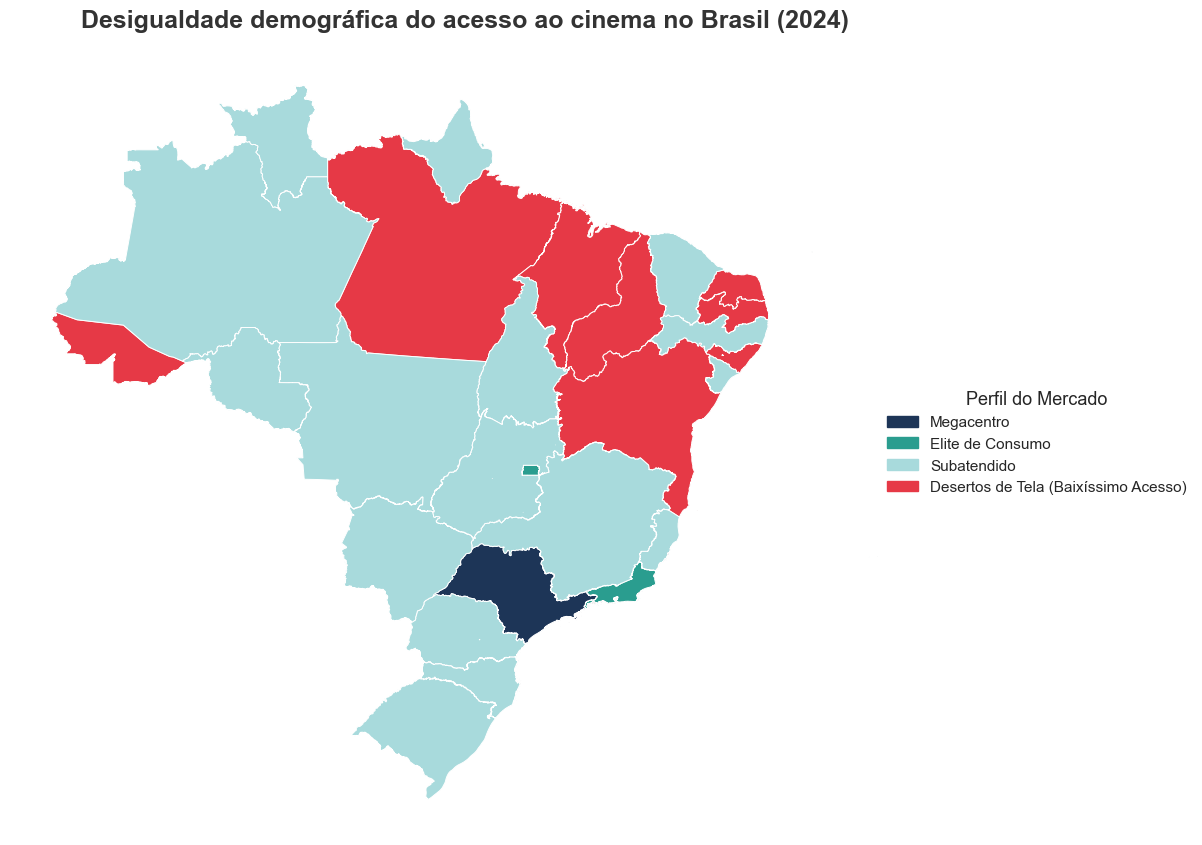

In [15]:
import matplotlib.patches as mpatches

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0), 'figure.facecolor':'white'})

cores_clusters = {
    'Megacentro': '#1D3557',                            
    'Elite de Consumo': '#2A9D8F',                                  
    'Subatendido': '#A8DADC',                           
    'Desertos de Tela (Baixíssimo Acesso)': '#E63946' 
}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

for cluster, dados_cluster in mapa_com_dados.groupby('Nome_Cluster'):
    cor = cores_clusters.get(cluster, '#CCCCCC')
    dados_cluster.plot(
        color=cor,
        ax=ax,
        edgecolor='white',
        linewidth=0.7
    )

ax.axis('off')

legend_handles = [
    mpatches.Patch(color=cor, label=label)
    for label, cor in cores_clusters.items()
]

ax.legend(
    handles=legend_handles,
    title='Perfil do Mercado',
    title_fontsize=13,
    fontsize=11,
    loc='center left',
    bbox_to_anchor=(0.95, 0.5),
    frameon=False 
)

plt.title(
    'Desigualdade demográfica do acesso ao cinema no Brasil (2024)', 
    fontsize=18, 
    fontweight='bold', 
    pad=16, 
    color='#333333'
)

plt.tight_layout()
plt.show()

O estado de São Paulo é o único classificado como "Megacentro". Isso explica por que a linha do Sudeste no gráfico de linhas sobre as regiões era tão mais alta. É o coração financeiro e de infraestrutura do país, onde a relação entre número de habitantes e salas de cinema é a mais confortável.

Rio de Janeiro e Distrito Federal formam o segundo escalão. São polos de alta renda e densidade urbana que conseguem manter uma infraestrutura de exibição de ponta, muito acima da média nacional.

Nos estados em vermelho o acesso a um cinema é baixíssimo. Milhões de pessoas vivem em cidades (muitas vezes de médio porte) que não possuem uma única sala de cinema em funcionamento. Para assistir a um filme na tela grande, grande parte dessa população precisaria viajar para capitais ou grandes centros regionais. A esmagadora maioria estão situadas no nordeste.

Isso inclusive gera o debate de que o aumento no números de salas em uma região não exatamente gera mais acesso, se essas salas ficam localizadas somente em grandes centros urbanos.

A maior parte do território nacional é considerada Subatendida. Isso indica que, embora essas regiões não sejam "desertos", a quantidade de cinemas ainda é insuficiente para o tamanho da população. Se houvesse mais investimentos (como a abertura de cinemas em cidades do interior), haveria público para consumir, o que corrobora aquela primeira matriz de correlação (mais salas = mais ingressos vendidos).

---

### **Os investimentos no mercado cinematográfico viabiliza um aumento na bilheteria dos filmes nacionais?**

Primeiro separamos o investimento anual que é feito na Ancine. Coletamos essa informação por meio do dataframe despesas por orgão.

In [1478]:
df_ancine = df_orgao[df_orgao["entidade_vinculada"] == "20203 - Agência Nacional do Cinema"]
df_ancine_ano = df_ancine.groupby(df_ancine["mes_ano"].dt.year)["Valor Pago"].sum().reset_index()
df_ancine_ano.to_csv("dados/despesas_ancine_ano.csv", index=False, encoding="utf-8")
df_ancine_ano.head(15)

,mes_ano,Valor Pago
0,2014,8.754024e+12
1,2015,9.707336e+12
2,2016,9.372787e+12
3,2017,1.915510e+13
4,2018,8.899229e+12
5,2019,1.020075e+13
6,2020,8.991922e+12
7,2021,1.164833e+13
8,2022,8.807306e+12
9,2023,7.439183e+13


In [ ]:
!pip install odfpy
arquivo_ods = 'dados/31072025_TabelasFSA.ods'
nome_da_aba = '7__Invest_'
arquivo_saida = 'investimentos.csv'

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,Investimentos Retornáveis no Setor Audiovisual...,NaN,NaN,NaN
1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados...,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000


In [1495]:
df_FSA = pd.read_excel(arquivo_ods, engine='odf', sheet_name=nome_da_aba)

df_FSA.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,Investimentos Retornáveis no Setor Audiovisual...,NaN,NaN,NaN
1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados...,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000


In [1496]:
df_FSA.columns = df_FSA.iloc[1]
df_FSA.head()

1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
0,NaN,Investimentos Retornáveis no Setor Audiovisual...,NaN,NaN,NaN
1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados...,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000


In [1497]:
df_FSA = df_FSA.drop(index=[0, 1]) 
df_FSA.head()

1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000
5,NaN,2010,54059817,0,15650780.12
6,NaN,2011,157275011,54059817,31325735.72


In [1498]:
df_FSA = df_FSA.drop(df_FSA.columns[0], axis=1) 
df_FSA.head()

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72


In [1499]:
df_FSA.head(30)

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72
7,2012,369190348,53309653,44587284.09
8,2013,400000000,121500000,78465397.52
9,2014,414000000,65000000,89125408.32
10,2015,500000000,487811889,218904814.15
11,2016,591765859,699782502,270558303.61


In [1500]:
df_FSA = df_FSA.drop(index=df_FSA.index[19:30])
df_FSA.head(30) 

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72
7,2012,369190348,53309653,44587284.09
8,2013,400000000,121500000,78465397.52
9,2014,414000000,65000000,89125408.32
10,2015,500000000,487811889,218904814.15
11,2016,591765859,699782502,270558303.61


In [ ]:
df_FSA["Ano"] = df_FSA["Ano"].str.replace(" ", "").str.replace("*", "")
df_FSA["Ano"] = pd.to_datetime(df_FSA["Ano"], format='%Y').dt.year
df_FSA.columns = df_FSA.columns.str.strip()
df_FSA["Execução Financeira (recursos disponibilizados ao FSA)1"] = df_FSA["Execução Financeira (recursos disponibilizados ao FSA)1"].astype(float)

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,NaN,15000000,0.000000e+00,0
3,NaN,38549335,3.854934e+07,0
4,NaN,84904972,8.490497e+07,4500000
5,NaN,54059817,0.000000e+00,15650780.12
6,NaN,157275011,5.405982e+07,31325735.72
7,NaN,369190348,5.330965e+07,44587284.09
8,NaN,400000000,1.215000e+08,78465397.52
9,NaN,414000000,6.500000e+07,89125408.32
10,NaN,500000000,4.878119e+08,218904814.15
11,NaN,591765859,6.997825e+08,270558303.61


In [1502]:
df_bilheteria = pd.read_csv("dados/Bilheteria_N x Bilheteria_IN(2014-2025).csv", encoding="utf-8")
df_correlacao = pd.merge(df_ancine_ano, df_bilheteria, left_on="mes_ano", right_on="ano", how="inner")
df_correlacao = df_correlacao.drop("ano", axis=1)
df_correlacao = pd.merge(df_correlacao, df_FSA, left_on="mes_ano", right_on="Ano", how="inner")

df_correlacao.head(15)

,mes_ano,Valor Pago,bilheteria_internacional,bilheteria_nacional,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
0,2025,1.056417e+14,1428448862,182193506,2025.0,645000000,234000000.0,235944405


In [1503]:
df_correlacao = df_correlacao.drop(["Ano", "Empenho do Orçamento do FSA", "Recursos Desembolsados2"], axis=1)
correlacao = df_correlacao["Valor Pago"].corr(df_correlacao["bilheteria_nacional"])
print(f"O coeficiente de correlação é: {correlacao:.2f}")

O coeficiente de correlação é: nan


c:\Users\kaiol\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\kaiol\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\kaiol\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


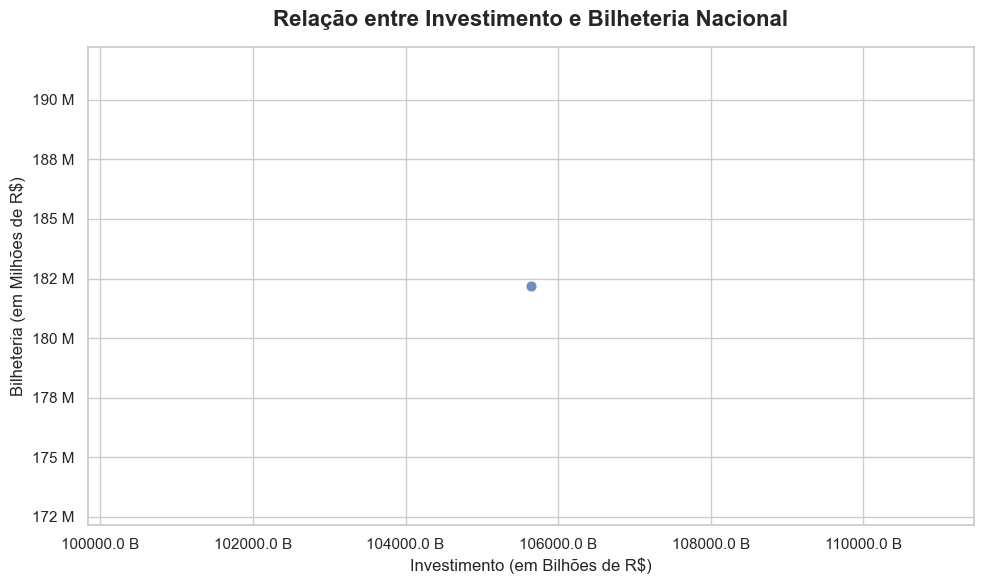

In [1504]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.regplot(
    data=df_correlacao, 
    x="Valor Pago", 
    y="bilheteria_nacional",
    scatter_kws={'s': 60, 'alpha': 0.8, 'edgecolor': 'white', 'linewidths': 0.5}, 
    line_kws={'color': '#e74c3c', 'linewidth': 2} 
)

plt.title("Relação entre Investimento e Bilheteria Nacional", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Investimento (em Bilhões de R$)", fontsize=12)
plt.ylabel("Bilheteria (em Milhões de R$)", fontsize=12)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:.1f} B'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f} M'))

plt.tight_layout()
plt.show()

---

### **Conclusão**

A análise revelou padrões fundamentais sobre o acesso e o consumo de cinema no país ao longo das últimas décadas. Constatou-se que a infraestrutura é um fator determinante, a frequência que uma pessoa vai ao cinema, dentre outras coisa, está também relacionada a disponibilidade de salas de uma região. A simples passagem do tempo não explica a frequência nos cinemas, evidenciando que a expansão de salas é vital para o setor.

Em termos regionais, observamos um movimento de descentralização na última década, com o Nordeste ultrapassando o Sul e se consolidando como o segundo maior mercado exibidor do país. No entanto, esse crescimento não evidenciou uma maior democratização do cinema na região, já que, por geralmente estarem localizados em shoppings, as salas ficam exclusivas para os centros urbanos dos estados. Em contrapartida, as regiões Norte e Centro-Oeste ainda enfrentam enormes desafios geográficos e econômicos, apresentando os menores índices de salas. Através do algoritmo de agrupamento (K-Means), ficou evidente a desigualdade no país. Além disso, a análise evidenciou o impacto brutal e sem precedentes da pandemia a partir de 2021, que derrubou drasticamente o público e o número de cinemas, mostrando uma recuperação muito lenta.

Esses resultados são extremamente importantes pois jogam luz sobre a desigualdade no acesso à cultura no Brasil. Eles fornecem insumos baseados em dados para que políticas públicas (como os incentivos do Fundo Setorial do Audiovisual - FSA e Ancine) e investimentos privados sejam direcionados para as regiões com pouco acesso, democratizando a experiência cinematográfica em todo país.

**Limitações:**

Durante o desenvolvimento do projeto, enfrentamos algumas limitações referentes aos dados:

- A coleta via web scraping e extração de PDFs (Ancine, Filme B) gerou tabelas mal estruturadas, com informações misturadas ao rodapé e variáveis numéricas formatadas como string (ex: "196" significando "1.96"), exigindo um exaustivo trabalho de limpeza e pré-processamento.
- A presença de diversos dados ausentes/nulos dependeu de tratamentos específicos para não distorcer as análises.
- A análise focou na relação entre população e número de salas, mas o projeto não cruzou aprofundadamente dados de renda média de cada região, que é um fator crucial para explicar a existência de cinemas.
- A falta de informações sobre o cinema brasileiro para anos anteriores ao século 21.
- A falta de informações sobre o fomento destinado aos orgãos de interesse antes dos anos de 2014, para ter acesso aos dados, tendo que acessar o Siafi.

**Trabalhos Futuros e Melhorias:**

Para aprimorar esta pesquisa no futuro, sugerimos as seguintes melhorias e próximos passos:

- Incorporar dados do IBGE sobre a renda per capita e o IDH de cada estado/município para avaliar a correlação entre poder de compra e a classificação dos clusters.
- Adicionar dados sobre a assinatura de plataformas de streaming no Brasil no mesmo período, aplicando regressão para analisar o quanto a concorrência digital afetou a venda de ingressos nos cinemas físicos.
- Treinar modelos de regressão avançados ou séries temporais para prever em que ano o mercado exibidor brasileiro retornará aos patamares pré-pandemia (2019).